<h1 style="color:#1a5276;">Predicción de ROP — Pozo 1, Mar del Norte-Noruega</h1>

### Punto de partida real de este proyecto: limpieza desde cero de un pozo crudo

El dataset público de la Universidad de Stavanger (bloque 15/9, Mar del Norte) tiene 7 pozos, y **la mayoría de ellos ya vienen procesados y limpios**. Para trabajar en el proceso completo de limpieza de datos vamos a tomar **un pozo en su forma cruda, tal cual sale de los sensores**, y aplicar nuestro propio criterio: entender las columnas, los nulos, decidir qué hacer con los valores imposibles, encontrar y explicar los outliers.

### ¿Qué es el ROP y por qué es la variable central de este proyecto?

**ROP (Rate of Penetration / velocidad de penetración)** es qué tan rápido avanza el trépano perforando la roca — se mide en metros por hora. Es la variable más importante en la operación de perforación porque **el tiempo de taladro es el costo más grande de perforar un pozo**: cada hora que el equipo está perforando (o parado, o perforando lento) cuesta dinero real, sin importar si avanza rápido o despacio. Predecir el ROP con anticipación, a partir de los parámetros de perforación (peso, rotación, torque, etc.), permite: planificar cuánto va a tardar un pozo nuevo antes de perforarlo, detectar en tiempo real si algo anda mal, y ajustar los parámetros de perforación para maximizar la velocidad sin dañar el equipo ni la formación.

### Por qué este pozo en particular

Entre los pozos crudos disponibles, dudábamos entre el pozo 1 y el pozo 6 — los dos manejables en tamaño. Antes de elegir, comparamos su profundidad real:

| | Pozo 1 | Pozo 6 |
|---|---|---|
| Profundidad | 0 – 915 m | 0 – 634 m |
| Filas | 21.013 | 13.830 |

Elegimos el **pozo 1** por tener mayor profundidad y más volumen de datos — nos da más terreno para analizar sin ser tan pesado como los pozos más largos del dataset (2 y 3, que superan los 30 MB en crudo).

### Objetivo de este notebook

Limpiar el **pozo 1** desde su archivo crudo, con el mismo nivel de detalle y criterio que ya veníamos aplicando, de forma que el resultado final sea **comparable y combinable** con el resto de pozos (incluidas las mismas columnas, para poder juntarlos más adelante en un solo dataset de entrenamiento). El **pozo 5 sigue reservado sin tocar**, para usarlo como prueba final del modelo cuando llegue el momento.



## 1. Preparción del Entorno

### 1.1 Cargar el archivo y diagnóstico inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?id=1JdstKio5ZpbJ9GHLTXwq97BpZwrCQ1Yn')
print('Shape:', df.shape)
df.head()

Shape: (21013, 65)


,Unnamed: 0,Measured Depth m,MWD Continuous Inclination dega,MWD Magnetic Toolface dega,Weight on Bit kkgf,Average Hookload kkgf,Bit run number unitless,MWD Shock Risk unitless,Active Tank Volume m3,"Gas, Nor-C4 ppm",...,Gyro Temperature degC,ARC Annular Pressure kPa,ARC Equivalent Circulating Density g/cm3,MWD Gravity Toolface dega,Gyro Continuous Inclination dega,Gyro Inertial ToolFace dega,GYRO_STAT2 unitless,IMP/ARC Attenuation Resistivity 40-in. at 2 MHz ohm.m,Annular Temperature degC,IMP/ARC Phase-Shift Resistivity 40-in. at 2 MHz ohm.m
0,0,109.271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,109.423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,109.576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,109.728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,109.880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Diagnóstico inicial en un solo paso:** `df.info()` muestra, columna por columna, el tipo de dato y cuántos valores no-nulos tiene cada una — todo junto, sin tener que armar por separado un `.dtypes` y un `.isna().sum()`:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21013 entries, 0 to 21012
Data columns (total 65 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Unnamed: 0                                             21013 non-null  int64  
 1   Measured Depth m                                       21013 non-null  float64
 2   MWD Continuous Inclination dega                        1385 non-null   float64
 3   MWD Magnetic Toolface dega                             550 non-null    float64
 4   Weight on Bit kkgf                                     699 non-null    float64
 5   Average Hookload kkgf                                  699 non-null    float64
 6   Bit run number unitless                                18783 non-null  float64
 7   MWD Shock Risk unitless                                1408 non-null   float64
 8   Active Tank Volume m3                         

### 1.2 Los nombres de las columnas

**Un paso que decidimos NO hacer, a propósito: normalizar los nombres de columna** (pasar todo a minúsculas con guión bajo, como `weight_on_bit_kkgf`). Lo chequeamos con código antes de decidir:

In [ ]:
problemas = [c for c in df.columns if c != c.strip() or '  ' in c]
print('Columnas con espacios de más (al principio/final, o dobles):', len(problemas))

Columnas con espacios de más (al principio/final, o dobles): 0


**Resultado: 0.** Ninguna de las 65 columnas tiene el problema que normalmente justifica normalizar (espacios sueltos, dobles espacios) — ya vienen limpias de origen.

Y hay una razón más importante todavía para NO normalizar acá: los 6 pozos ya procesados (`USROP_A 0/2/3/4/6...csv`) usan el formato original, con mayúsculas y espacios (`Weight on Bit kkgf`). Cambiar el formato de nuestras columnas rompería la compatibilidad que necesitamos para combinar los 7 pozos en un solo dataset de entrenamiento — acá normalizar sería contraproducente, al revés de lo que conviene en un dataset que no tiene que calzar con nada más.

**65 columnas, 21.013 filas** — mucho más grande que cualquier archivo ya procesado. Este es el tamaño real de un registro de pozo sin curar.

### 1.3 Filas duplicadas y variables sin información

**Dos chequeos rápidos más, antes de seguir: filas duplicadas y columnas sin variabilidad.**

In [ ]:
print('Filas duplicadas:', df.duplicated().sum())

variabilidad = df.nunique().sort_values()
print()
print('Columnas con menos valores distintos:')
print(variabilidad.head(8))

Filas duplicadas: 0

Columnas con menos valores distintos:
MWD Shock Risk unitless    1
Gas, C2 ppm                1
nameWellbore               1
Pass Name unitless         1
NRPM_RT unitless           2
Gas, Nor-C5 ppm            2
Gas, C3 ppm                2
Gas, Nor-C4 ppm            2
dtype: int64


**0 filas duplicadas** — no hace falta borrar nada por ese lado. Y esto confirma con código algo que ya habíamos dicho por criterio en la sección 2: `nameWellbore` y `Pass Name` tienen exactamente **1 solo valor distinto** en las 21.013 filas — no varían nunca, así que no pueden aportarle nada a un modelo. De paso aparecen dos casos nuevos con el mismo problema (`Gas, C2 ppm` y `MWD Shock Risk unitless`, con 1 solo valor) — ya estaban descartadas igual, por pertenecer a los grupos de "Gas/seguridad" y "Choques/vibración" que no sirven para ROP, pero es una segunda confirmación independiente de que esa decisión fue correcta.

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Conclusión sección 1:** el archivo carga bien, sin duplicados, con nombres de columna ya limpios (no hace falta normalizarlos, y de hecho normalizarlos rompería la compatibilidad con los pozos ya procesados). El `df.info()` y el chequeo de variabilidad ya dejan entrever el problema central del pozo — muchísimos nulos y varias columnas sin ninguna variación — que vamos a diagnosticar en profundidad en la sección 2.

</div>

## 2. Entender las 65 columnas: qué mide cada grupo

Antes de tocar nulos o correlaciones, conviene entender **de dónde salen tantas columnas**. Un pozo real no se mide con un solo sensor — corren varios sistemas de medición en simultáneo, cada uno con sus propias columnas, y todos terminan volcados en la misma tabla:

In [ ]:
for c in df.columns:
    print('-', c)

- Unnamed: 0
- Measured Depth m
- MWD Continuous Inclination dega
- MWD Magnetic Toolface dega
- Weight on Bit kkgf
- Average Hookload kkgf
- Bit run number unitless
- MWD Shock Risk unitless
- Active Tank Volume m3
- Gas, Nor-C4 ppm
- Hole Depth (TVD) m
- MWD Collar RPM rpm
- Average Standpipe Pressure kPa
- Corr. Drilling Exponent unitless
- Mud Temperature In degC
- Gas, C3 ppm
- MWD Total Shocks unitless
- MWD Shock Peak m/s2
- Average Surface Torque kN.m
- MWD Turbine RPM rpm
- NRPM_RT unitless
- MWD Continuous Azimuth dega
- RHX_RT unitless
- Gas, Nor-C5 ppm
- Mud Density Out g/cm3
- MWD DNI Temperature degC
- Total Bit Revolutions unitless
- MWD Gamma Ray (API BH corrected) gAPI
- Gas, C2 ppm
- Extrapolated Hole TVD m
- Gas, Iso-C4 ppm
- Rate of Penetration (5ft avg) m/h
- Bit Drill Distance m
- AJAM_MWD unitless
- Mud Density In g/cm3
- Mud Flow In L/min
- Lag Depth (TVD) m
- RGX_RT unitless
- H2S Average ppm
- Mud Temperature Out degC
- Gas, Iso-C5 ppm
- Mud Flow Out % %
- MWD

Agrupamos las 65 columnas por qué mide cada una — con código, no a ojo. Como pandas no puede inferir el significado físico de cada nombre, armamos un clasificador por palabras clave (un diccionario de reglas) y después sí usamos `groupby` para contar cuántas hay en cada grupo:

In [ ]:
def clasificar(col):
    c = col.lower()
    if col == 'name':
        return 'Diámetro de mecha (caso especial, ver 3.2)'
    if 'namewellbore' in c or 'pass name' in c:
        return 'Identificadores (texto)'
    if col == 'Unnamed: 0':
        return 'Índice de fila (sin info)'
    if 'gas' in c or 'h2s' in c:
        return 'Gas / seguridad'
    if 'gamma ray' in c:
        return 'Gamma Ray (litología)'
    if 'resistivity' in c:
        return 'Resistividad'
    if any(k in c for k in ['inclination', 'toolface', 'azimuth', 'gyro_stat', 'ajam_mwd']):
        return 'Navegación direccional'
    if any(k in c for k in ['shock', 'stick-slip']):
        return 'Choques / vibración'
    if any(k in c for k in ['dni temperature', 'gyro temperature']):
        return 'Temperatura de herramienta'
    if any(k in c for k in ['mud ', 'tank volume', 'annular', 'ecd', 'circulating density']):
        return 'Lodo (mud)'
    if any(k in c for k in ['measured depth', 'hole depth', 'hole tvd', 'weight on bit', 'hookload',
                            'standpipe pressure', 'surface torque', 'rotary speed',
                            'rate of penetration', 'bit drill', 'bit run', 'bit revolutions',
                            'drilling exponent', 'lag depth', 'collar rpm', 'turbine rpm',
                            'nrpm_rt', 'rhx_rt', 'rgx_rt']):
        return 'Perforación / superficie'
    return 'Sin clasificar'

tabla_grupos = pd.DataFrame({'Columna': df.columns})
tabla_grupos['Grupo'] = tabla_grupos['Columna'].apply(clasificar)

print('¿Quedó alguna sin clasificar?', (tabla_grupos['Grupo'] == 'Sin clasificar').sum())

¿Quedó alguna sin clasificar? 0


In [ ]:
resumen_grupos = tabla_grupos.groupby('Grupo').agg(
    Cantidad=('Columna', 'count'),
    Ejemplos=('Columna', lambda x: ', '.join(list(x)[:3]))
).sort_values('Cantidad', ascending=False)

resumen_grupos

,Cantidad,Ejemplos
Grupo,,
Perforación / superficie,21,"Measured Depth m, Weight on Bit kkgf, Average ..."
Lodo (mud),10,"Active Tank Volume m3, Mud Temperature In degC..."
Navegación direccional,9,"MWD Continuous Inclination dega, MWD Magnetic ..."
Gas / seguridad,9,"Gas, Nor-C4 ppm, Gas, C3 ppm, Gas, Nor-C5 ppm"
Choques / vibración,5,"MWD Shock Risk unitless, MWD Total Shocks unit..."
Resistividad,3,IMP/ARC Phase-Shift Resistivity 16-in. at 2 MH...
Gamma Ray (litología),2,"MWD Gamma Ray (API BH corrected) gAPI, ARC Gam..."
Temperatura de herramienta,2,"MWD DNI Temperature degC, Gyro Temperature degC"
Identificadores (texto),2,"Pass Name unitless, nameWellbore"


**Y ahora sí, el criterio de dominio — cuáles de estos grupos tienen relación real con el ROP:**

| Grupo | ¿Sirve para ROP? |
|---|---|
| **Perforación / superficie** | **Sí — el núcleo, lo que el operador controla directamente** |
| **Lodo (mud)** | **Parcialmente sí** — Flow y Density afectan la limpieza del pozo y la hidráulica en la mecha |
| **Gamma Ray (litología)** | **Sí** — es la aproximación a litología: más arcilla, distinto comportamiento de ROP |
| Gas / seguridad | No — son variables de control de seguridad, no de mecánica de perforación |
| Resistividad | No — mide propiedades eléctricas de la roca para evaluación geológica, no para perforar |
| Navegación direccional | No — le dice al direccional hacia dónde apunta el pozo, no tiene relación mecánica con la velocidad de avance |
| Choques / vibración | No la usamos ahora, pero podría servir más adelante para detectar disfunciones mecánicas |
| Temperatura de herramienta | No — temperatura de la herramienta en sí, no del proceso de perforación |
| Identificadores (texto) | No — no varían dentro del pozo, no aportan información |
| Índice de fila | No — es un artefacto de exportación del CSV, no un dato del pozo |

**Un caso aparte:** la columna `name` también es texto, pero a diferencia de las otras dos, **sí varía** — más adelante (sección 3.2) vamos a ver que en realidad describe el diámetro de mecha en uso, no es un identificador vacío. Por eso no la descartamos con el resto, la investigamos aparte antes de decidir.

**Conclusión:** de los grupos de la tabla, solo 2-3 tienen relación real con el ROP. Esto nos permite descartar la gran mayoría de las columnas **por criterio, sin necesitar ningún cálculo** — no hace falta correlación para saber que un giroscopio de orientación no debería predecir velocidad de perforación.

**Por qué varias empiezan con "Average":** `Average Rotary Speed`, `Average Standpipe Pressure`, `Average Surface Torque`, `Average Hookload` fluctúan muy rápido en la realidad (vibración de la sarta, ajustes del perforador, roce con la pared del pozo) — reportar el valor instantáneo sería puro ruido. El sistema de adquisición del rig ya viene calculando un **promedio sobre una ventana corta de tiempo** antes de reportar cada lectura. No es algo que hicimos nosotras ni el dataset — viene así desde el sensor.

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Conclusión sección 2:** de las 65 columnas originales, solo el grupo de "perforación/superficie" (~11 columnas) es claramente relevante para predecir ROP. El resto (gas/seguridad, resistividad, navegación direccional, vibración/temperatura de herramienta, identificadores de texto) no aporta — esta tabla fue el primer filtro, antes de mirar cualquier estadística o correlación.

</div>

## 3. Selección de columnas

Con la tabla de la sección 2 como base, nos quedamos con:

- `Measured Depth m`, `Hole Depth (TVD) m` — las dos formas de medir profundidad.
- `Weight on Bit kkgf` — peso aplicado sobre el trépano.
- `Average Surface Torque kN.m` — resistencia a la rotación medida en superficie, en unidades de torque real.
- `Average Rotary Speed rpm` — velocidad de rotación de la sarta.
- `Average Standpipe Pressure kPa` — presión de bombeo del lodo.
- `Average Hookload kkgf` — peso que cuelga del gancho, sin apoyar en el fondo.
- `Mud Flow In L/min`, `Mud Density In g/cm3` — caudal y densidad del lodo bombeado.
- `Rate of Penetration m/h` — nuestra variable objetivo.
- `MWD Gamma Ray (API BH corrected) gAPI` — la aproximación a litología.
- `name` — todavía sin tocar; la vamos a investigar en un momento, antes de decidir qué hacer con ella.


### 3.1 Eliminar el resto de las columnas

Ahora sí, el paso explícito: armamos la lista de las 12 que nos quedamos, calculamos cuáles son **todas las demás** (65 - 12 = 53), y las eliminamos con `.drop()`.

In [ ]:
columnas_a_mantener = [
    'Measured Depth m', 'Hole Depth (TVD) m', 'Weight on Bit kkgf',
    'Average Surface Torque kN.m', 'Average Rotary Speed rpm', 'Average Standpipe Pressure kPa',
    'Average Hookload kkgf', 'Mud Flow In L/min', 'Mud Density In g/cm3',
    'Rate of Penetration m/h', 'MWD Gamma Ray (API BH corrected) gAPI', 'name',
]

columnas_a_eliminar = [c for c in df.columns if c not in columnas_a_mantener]
print('Cuántas se eliminan:', len(columnas_a_eliminar))
print(columnas_a_eliminar)

Cuántas se eliminan: 53
['Unnamed: 0', 'MWD Continuous Inclination dega', 'MWD Magnetic Toolface dega', 'Bit run number unitless', 'MWD Shock Risk unitless', 'Active Tank Volume m3', 'Gas, Nor-C4 ppm', 'MWD Collar RPM rpm', 'Corr. Drilling Exponent unitless', 'Mud Temperature In degC', 'Gas, C3 ppm', 'MWD Total Shocks unitless', 'MWD Shock Peak m/s2', 'MWD Turbine RPM rpm', 'NRPM_RT unitless', 'MWD Continuous Azimuth dega', 'RHX_RT unitless', 'Gas, Nor-C5 ppm', 'Mud Density Out g/cm3', 'MWD DNI Temperature degC', 'Total Bit Revolutions unitless', 'Gas, C2 ppm', 'Extrapolated Hole TVD m', 'Gas, Iso-C4 ppm', 'Rate of Penetration (5ft avg) m/h', 'Bit Drill Distance m', 'AJAM_MWD unitless', 'Lag Depth (TVD) m', 'RGX_RT unitless', 'H2S Average ppm', 'Mud Temperature Out degC', 'Gas, Iso-C5 ppm', 'Mud Flow Out % %', 'MWD Stick-Slip PKtoPK RPM rpm', 'Bit Drill Time h', 'Gas, C1 ppm', 'Pass Name unitless', 'Gas %', 'nameWellbore', 'ARC Gamma Ray (BH corrected) gAPI', 'IMP/ARC Phase-Shift Resis

In [ ]:
df_reducido = df.drop(columns=columnas_a_eliminar)
print('Shape después de eliminar:', df_reducido.shape)

Shape después de eliminar: (21013, 12)


Antes de seguir, miramos el tipo de dato de cada una de las 12 columnas que quedaron — así vemos de un vistazo cuáles ya son números y cuál todavía no.

In [ ]:
df_reducido.dtypes

,0
Measured Depth m,float64
Weight on Bit kkgf,float64
Average Hookload kkgf,float64
Hole Depth (TVD) m,float64
Average Standpipe Pressure kPa,float64
Average Surface Torque kN.m,float64
MWD Gamma Ray (API BH corrected) gAPI,float64
Mud Density In g/cm3,float64
Mud Flow In L/min,float64
Rate of Penetration m/h,float64


Como se ve, **todas son `float64` menos `name`, que es `object` (texto)** — es la única que todavía necesita trabajo antes de poder usarse en cálculos o correlaciones. Por eso la investigamos aparte a continuación.

### 3.2 Qué hay realmente adentro de la columna `name`


In [ ]:
df_reducido['name'].value_counts()

,count
name,
Real Time MWD/LWD Mudlog Data - 17.5 in. section - MD Log,19018
Real Time MWD Mudlog data - 36 in. section - MD Log,1995


In [ ]:
print(df_reducido.columns)

Index(['Measured Depth m', 'Weight on Bit kkgf', 'Average Hookload kkgf',
       'Hole Depth (TVD) m', 'Average Standpipe Pressure kPa',
       'Average Surface Torque kN.m', 'MWD Gamma Ray (API BH corrected) gAPI',
       'Mud Density In g/cm3', 'Mud Flow In L/min', 'Rate of Penetration m/h',
       'Average Rotary Speed rpm', 'name'],
      dtype='object')


**Ahí está la explicación:** `name` no es un identificador ni texto libre — son solo **2 valores posibles**, y cada uno describe **con qué diámetro de mecha se estaba perforando** en esa fila ("17.5 in. section" o "36 in. section"). Es el nombre que le puso el sistema de registro a ese dato, pero el contenido real es el tramo/sección del pozo.

### 3.3 Convertir el diámetro (de texto a milímetros) y renombrar las columnas finales



**Por qué no usamos `get_dummies`/`OneHotEncoder` ni `LabelEncoder` acá (encoding):** `name` es una variable categórica de texto, y en principio ahí es donde entrarían esos métodos. Pero no los usamos, a propósito:

- **`OneHotEncoder`/`get_dummies`** crearía una columna binaria por cada valor (`es_36in`, `es_17.5in`) — funciona, pero **descarta la magnitud física real** del diámetro; el modelo vería "categoría A" y "categoría B", sin ninguna noción de que una mecha es más del doble de ancha que la otra.
- **`LabelEncoder`** asignaría un número arbitrario (0, 1) sin relación con el valor real — y peor, **inventa un orden** que la categoría no tiene (por eso la profesora la reserva solo para la variable objetivo, nunca para predictoras).
- **Lo que hacemos en cambio (`.map()` con el diccionario de abajo)** convierte cada texto directamente al diámetro real en milímetros — conserva la magnitud física exacta, que es información real y útil para el modelo (a mayor diámetro, más área de corte), en vez de perderla en una codificación genérica.

Convertimos el texto de `name` a un número en milímetros, y de paso renombramos las columnas para que coincidan exactamente con los pozos ya procesados (`Diameter mm`, `USROP Gamma gAPI`). Al estar el resto de las variables en sistema métrico dejamos el Diámetro en mm.

In [ ]:
conversion_diametro = {
    'Real Time MWD  Mudlog data - 36 in. section - MD Log': 914.4,
    'Real Time MWD/LWD Mudlog Data - 17.5 in. section - MD Log': 444.5,
}
#conversion_diametro es un diccionario (tabla de equivalencias)
df_reducido['name'] = df_reducido['name'].map(conversion_diametro)
#.map() recorre cada fila de la columna name, busca ese texto exacto como clave en el diccionario, y
#lo reemplaza por el número que tiene asignado.

df_sel = df_reducido.rename(columns={
    'name': 'Diameter mm',
    'MWD Gamma Ray (API BH corrected) gAPI': 'USROP Gamma gAPI',
})
df_sel.shape

(21013, 12)

**Verificación:** chequeamos cómo quedaron las dos columnas a las que les cambiamos el contenido y/o el nombre (`name` → `Diameter mm`, y `MWD Gamma Ray (API BH corrected) gAPI` → `USROP Gamma gAPI`), para confirmar que el `.map()` y el `.rename()` funcionaron como esperábamos.

In [ ]:
# lista de columnas de df_sel, para ver con los propios ojos que 'name' ya no esta, y en su lugar aparecen los nuevos nombres
df_sel.columns.tolist()

['Measured Depth m',
 'Weight on Bit kkgf',
 'Average Hookload kkgf',
 'Hole Depth (TVD) m',
 'Average Standpipe Pressure kPa',
 'Average Surface Torque kN.m',
 'USROP Gamma gAPI',
 'Mud Density In g/cm3',
 'Mud Flow In L/min',
 'Rate of Penetration m/h',
 'Average Rotary Speed rpm',
 'Diameter mm']

In [ ]:
# tipo de dato de cada una -> las dos tienen que ser numericas (float), ya no texto
df_sel[['Diameter mm', 'USROP Gamma gAPI']].dtypes

,0
Diameter mm,float64
USROP Gamma gAPI,float64


In [ ]:
# Diameter mm deberia tener SOLO dos valores posibles (914.4 y 444.5), uno por cada tramo -> confirma que el .map() convirtio bien
df_sel['Diameter mm'].value_counts()

,count
Diameter mm,
444.5,19018
914.4,1995


In [ ]:
# estadistica basica de USROP Gamma gAPI, solo para chequear que los numeros tengan un rango razonable (no quedo nada raro del rename)
df_sel['USROP Gamma gAPI'].describe()

,USROP Gamma gAPI
count,3425.000000
mean,78.073665
std,28.810273
min,2.403000
25%,70.891000
50%,86.511000
75%,96.123000
max,242.710000


### ¿Por qué hay dos diámetros distintos en este pozo?

Pensalo como armar una serie de tubos que encajan uno dentro del otro, cada vez más finos — parecido a un telescopio que se pliega, o a unas muñecas rusas.

Un pozo no se perfora de una sola vez con el mismo ancho de punta a punta. Se hace por **tramos**, de arriba hacia abajo:

1. Se perfora el primer tramo con una mecha **grande** (en este pozo, 36 pulgadas → 914.4 mm), desde la superficie hasta cierta profundidad.
2. Ahí se mete un caño de acero (llamado "revestimiento" o *casing*) dentro de ese agujero, y se cementa en su lugar — esto sostiene las paredes del pozo, evita que se derrumbe, y sella esa zona del resto.
3. Para seguir perforando más profundo, hay que usar una mecha **más chica** (acá, 17.5 pulgadas → 444.5 mm), porque tiene que pasar por **adentro** del caño que ya se instaló — no puede ser más ancha que el tubo por el que tiene que entrar.
4. Si el pozo tuviera más tramos, se repetiría: perforar, poner otro caño más angosto todavía adentro del anterior, y así sucesivamente.

**¿Por qué no usar el mismo ancho todo el pozo?** Porque cada caño nuevo tiene que entrar dentro del anterior — es una limitación física, no una elección. Además, la parte más cercana a la superficie suele necesitar un revestimiento más grande y resistente por seguridad (paredes menos firmes, protección de capas de agua subterránea), mientras que en profundidad no hace falta tanto ancho, y permite aislar cada tramo antes de seguir perforando hacia zonas con presiones o formaciones distintas.

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**⚠️ Anticipo: esta sección de 36 in la vamos a descartar más adelante (sección 6.4)**

Todavía no llegamos ahí, pero conviene dejarlo anotado acá, que es donde se explica el diámetro. Dos motivos propios, encontrados con nuestros propios datos, más uno de compatibilidad:

- Es la sección donde aparecieron los valores físicamente imposibles de `Mud Density` y `Average Standpipe Pressure` (negativos) — ambos problemas están concentrados exclusivamente acá, no en el resto del pozo.
- Es una de las dos partes del problema de solapamiento de profundidad que vamos a resolver en 6.1-6.3 (comparte rango de profundidad con la sección de 17.5in).
- Además, ningún pozo ya procesado del dataset tiene esta sección — sacarla también deja nuestro pozo compatible para combinarlo con los otros 6.

Lo vamos a hacer explícito con código más adelante — esto es solo el aviso, para que no aparezca de sorpresa.

</div>

**Antes de tocar nulos, orden o filtros, dejamos una foto del estado crudo de las 12 columnas ya elegidas** — así en la sección 7 (data ya limpia) tenemos con qué compararla.

In [ ]:
df_sel.describe().round(2)

,Measured Depth m,Weight on Bit kkgf,Average Hookload kkgf,Hole Depth (TVD) m,Average Standpipe Pressure kPa,Average Surface Torque kN.m,USROP Gamma gAPI,Mud Density In g/cm3,Mud Flow In L/min,Rate of Penetration m/h,Average Rotary Speed rpm,Diameter mm
count,21013.00,699.00,699.00,20761.00,699.00,699.00,3425.00,718.00,699.00,699.00,699.00,21013.00
mean,470.02,3.90,101.27,473.41,13510.64,1.96,78.07,1.23,4036.39,59.99,163.13,489.11
std,241.73,3.07,4.06,239.47,4019.71,32.61,28.81,0.39,865.98,288.56,58.41,137.75
min,0.00,0.01,71.73,0.00,-666.00,-851.41,2.40,-8.82,0.00,0.20,0.00,444.50
25%,241.71,1.79,100.32,258.62,12591.00,2.28,70.89,1.27,4004.52,29.73,116.00,444.50
50%,443.21,3.74,101.51,448.02,14676.00,3.30,86.51,1.27,4449.13,40.85,196.00,444.50
75%,683.51,5.37,103.58,685.41,16316.50,4.94,96.12,1.27,4485.69,51.15,210.00,444.50
max,914.87,25.62,115.14,911.19,18251.00,10.21,242.71,1.33,4543.05,7059.40,212.00,914.40


## 4. Exploración de nulos (ya sobre las 12 columnas elegidas)

Ahora que ya sabemos con qué columnas vamos a trabajar, miramos cuántos nulos tiene cada una — mucho más simple que mirar las 65 originales.

In [ ]:
nulos = df_sel.isna().sum().sort_values()
pct_nulos = (nulos / len(df_sel) * 100).round(1)
pd.DataFrame({'nulos': nulos, 'porcentaje': pct_nulos})

,nulos,porcentaje
Measured Depth m,0,0.0
Diameter mm,0,0.0
Hole Depth (TVD) m,252,1.2
USROP Gamma gAPI,17588,83.7
Mud Density In g/cm3,20295,96.6
Average Hookload kkgf,20314,96.7
Average Surface Torque kN.m,20314,96.7
Weight on Bit kkgf,20314,96.7
Average Standpipe Pressure kPa,20314,96.7
Mud Flow In L/min,20314,96.7


**El patrón es claro:** casi todas las columnas de perforación tienen **96.7% de nulos** — casi todas el mismo porcentaje entre sí, lo cual no es casualidad. En un pozo real, hay **varios sistemas de medición trabajando en paralelo, cada uno con su propia frecuencia**:

- Los **sensores de superficie** (peso sobre la mecha, torque, presión de bombeo) están conectados al sistema de adquisición del taladro y reportan con cierta periodicidad, no en cada instante.
- Las **herramientas de fondo de pozo (MWD/LWD)**, que miden cosas como Gamma Ray, transmiten sus datos a superficie a través de pulsos de presión en el lodo — un método lento, así que reportan con mucha menos frecuencia todavía (por eso el Gamma Ray tiene un porcentaje de nulos distinto al resto).
- Ambos sistemas, con sus propios relojes y frecuencias, se **combinan en una sola tabla indexada por profundidad** al momento de exportar el archivo. El resultado: en cualquier fila puntual, es raro que *todos* los sensores tengan una lectura nueva al mismo tiempo.

**Por qué esto importa para la limpieza:** esto no es un error de calidad del dato, es la naturaleza de cómo se arma un archivo de pozo combinando múltiples fuentes. Por eso no podemos simplemente borrar cualquier fila con algún nulo — eliminaríamos casi todo el pozo. Confirmamos esto:

In [ ]:
nucleo_perforacion = ['Weight on Bit kkgf', 'Rate of Penetration m/h', 'Average Surface Torque kN.m',
                       'Average Standpipe Pressure kPa', 'Average Rotary Speed rpm',
                       'Average Hookload kkgf', 'Mud Flow In L/min', 'Mud Density In g/cm3']

filas_completas = df_sel[nucleo_perforacion].notna().all(axis=1)
print('Filas donde TODO el núcleo de perforación está presente a la vez:', filas_completas.sum(), 'de', len(df_sel))

Filas donde TODO el núcleo de perforación está presente a la vez: 699 de 21013


Solo **699 de 21.013 filas (3.3%)** tienen todos los parámetros de perforación básicos al mismo tiempo. Si filtráramos así de estricto, perderíamos el 97% del pozo.

**Decisión:** en vez de borrar filas, vamos a **rellenar hacia adelante** (`ffill`) cada columna — cuando una fila no tiene una lectura nueva de un sensor, le asignamos la **última lectura real conocida** de ese sensor. Es el mismo criterio que usaron los investigadores que armaron los pozos ya procesados de este dataset — lo aplicamos acá nosotras mismas, desde cero.

**Para que quede clarísimo con números reales, esto es lo que pasaría si en vez de rellenar, borráramos directamente cualquier fila que tenga aunque sea un solo nulo, en cualquiera de las 12 columnas** (no solo el núcleo de 8):

In [ ]:
filas_sin_ningun_nulo = df_sel.dropna(how='any')
print('Filas sin absolutamente ningún nulo en ninguna de las 12 columnas:', len(filas_sin_ningun_nulo), 'de', len(df_sel))

Filas sin absolutamente ningún nulo en ninguna de las 12 columnas: 7 de 21013


Quedarían solo **7 filas de 21.013**. Prácticamente nada — imposible entrenar un modelo con eso.

Esto pasa porque `dropna` exige que **todas** las columnas tengan dato en la misma fila al mismo tiempo, y como cada sensor reporta en su propio momento (sección de arriba), es rarísimo que los 12 coincidan a la vez. Por eso la solución no es borrar, es **rellenar** (`ffill`/`bfill`) — cada sensor mantiene su último valor real conocido hasta que llega una lectura nueva, en vez de exigir que todos reporten en la misma fila exacta.

**Para verlo con más detalle, cuántas filas tiene realmente cada sensor (no solo el grupo del núcleo):**

In [ ]:
conteo_validos = df_sel.notna().sum().sort_values(ascending=False)
conteo_validos

,0
Measured Depth m,21013
Diameter mm,21013
Hole Depth (TVD) m,20761
USROP Gamma gAPI,3425
Mud Density In g/cm3,718
Weight on Bit kkgf,699
Average Hookload kkgf,699
Average Surface Torque kN.m,699
Average Standpipe Pressure kPa,699
Mud Flow In L/min,699


Esto confirma que no todos los sensores reportan con la misma frecuencia — hay al menos 3 grupos distintos:

| Grupo | Filas con dato real | Ejemplo |
|---|---|---|
| Siempre presente (es la estructura de la tabla, no un sensor con frecuencia propia) | ~21.000 | `Measured Depth`, `Diameter mm` |
| Herramienta de fondo de pozo (MWD), transmite por pulsos de lodo | 3.425 | `USROP Gamma gAPI` |
| Sensores de superficie, reportan juntos y con mucha menos frecuencia | ~699-718 | `Weight on Bit`, `Rate of Penetration`, `Mud Density`, etc. |

Por eso el `Mud Density` (718 filas) sí entra en el mismo grupo que el núcleo de perforación (699), pero el Gamma Ray (3.425) es un grupo aparte, con su propia frecuencia de reporte.

### ¿El faltante es aleatorio?


**Clasificando el patrón de nulos (MCAR / MAR / MNAR) — comprobado con código, no solo afirmado:**

La pregunta clave: ¿falta el dato de `Weight on Bit` en una fila cualquiera, o falta *junto con* otras variables, de forma predecible? Armamos un indicador de "está nulo o no" para tres columnas, y medimos qué tan ligados están entre sí:

In [ ]:
wob_nulo = df_sel['Weight on Bit kkgf'].isna()
torque_nulo = df_sel['Average Surface Torque kN.m'].isna()
gamma_nulo = df_sel['USROP Gamma gAPI'].isna()

# correlacion entre los INDICADORES de nulo (no entre los valores) -> 1 = siempre coinciden, 0 = independientes/al azar
print('WOB nulo vs Torque nulo (mismo grupo de sensores):', wob_nulo.astype(int).corr(torque_nulo.astype(int)))
print('WOB nulo vs Gamma nulo (otro grupo, otra frecuencia):', wob_nulo.astype(int).corr(gamma_nulo.astype(int)))
print('% de filas donde WOB y Torque faltan exactamente juntos:', (wob_nulo == torque_nulo).mean() * 100, '%')

WOB nulo vs Torque nulo (mismo grupo de sensores): 1.0
WOB nulo vs Gamma nulo (otro grupo, otra frecuencia): -0.07682899489917477
% de filas donde WOB y Torque faltan exactamente juntos: 100.0 %


**Resultado real: WOB y Torque faltan juntos en el 100% de las filas (correlación = 1.0), mientras que WOB y Gamma casi no se relacionan (correlación ≈ -0.08).**

Eso es justamente la prueba de que **no es MCAR**: si la ausencia fuera puramente al azar, no habría ninguna razón para que dos columnas distintas falten exactamente en las mismas filas — la correlación entre sus indicadores de nulo daría cerca de 0, como pasa entre WOB y Gamma (grupos con frecuencia distinta). En cambio, WOB y Torque faltan *siempre juntos*, porque los dos pertenecen al mismo sensor de superficie y reportan en el mismo instante — es decir, **la ausencia se puede predecir perfectamente sabiendo a qué grupo de frecuencia pertenece cada variable** (algo observable, no el valor oculto de WOB en sí). Eso es la definición de **MAR**: la ausencia depende de algo que sí observamos (el grupo/patrón de reporte), no del valor que falta.

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**⚠️ Por qué coinciden tantas variables en 699 filas — y qué implica**

`Weight on Bit`, `Torque`, `RPM`, `Standpipe Pressure`, `Hookload`, `Mud Flow`, `Mud Density` y `ROP` coinciden casi exactamente en 699 filas reales (de 21.013) porque **reportan todos juntos, en el mismo instante** — son los sensores de superficie, que comparten un solo sistema de adquisición (tabla de la sección 4).

Hay algo más de fondo acá: la profundidad (`Measured Depth m`) se mide con muchísima más finura que eso — el paso más chico registrado en este pozo es de **3 milímetros** entre una fila y la siguiente. O sea, el eje de la tabla tiene resolución de milímetros, pero la información real de estos sensores solo se actualiza, en promedio, una vez cada varios metros. Cuando más adelante entrenemos un modelo con esta tabla, va a evaluarse fila por fila, a esa resolución fina — aunque, para el núcleo de variables, la información real detrás de cada fila cambie mucho menos seguido de lo que parece.

**Esta es, en el fondo, la razón por la que más adelante usamos `ffill`/`bfill` (sección 6.5):** no hay forma de tener una medición real en cada milímetro — el `ffill` es, literalmente, la técnica que rellena esa diferencia de resolución, sosteniendo el último valor real conocido hasta que llega uno nuevo. Todo lo que viene después (secciones 6 en adelante) es la respuesta a este problema que estamos planteando acá.

</div>

## 5. Correlación con el ROP, calculada ANTES de rellenar

Con las 12 columnas ya elegidas por criterio, miramos qué tan relacionada está cada una con el ROP **usando los datos tal cual vienen**, sin rellenar todavía — así tenemos evidencia real, no solo la selección por dominio de la sección 3.

In [ ]:
resultados = []  # lista vacia donde vamos guardando (columna, correlacion, cuantas filas se usaron)

for col in df_sel.columns:
    if col == 'Rate of Penetration m/h':
        continue  # no tiene sentido calcular la correlacion del ROP consigo mismo, la saltamos

    # nos quedamos solo con las filas donde AMBAS columnas (ROP y la columna actual) tienen dato al mismo tiempo
    solapamiento = df_sel[['Rate of Penetration m/h', col]].dropna()
    n = len(solapamiento)  # cuantas filas quedaron con ese solapamiento -> el N que mostramos despues en la tabla

    # si hay menos de 2 filas no se puede calcular una correlacion real -> ponemos NaN para no inventar un numero
    corr = solapamiento['Rate of Penetration m/h'].corr(solapamiento[col]) if n > 1 else float('nan')

    resultados.append((col, corr, n))  # guardamos el resultado de esta columna

# ordenamos por el VALOR ABSOLUTO de la correlacion (asi -0.5 y +0.5 quedan juntos, las dos son relaciones fuertes)
# las que dieron NaN quedan al final (por eso el -1 en ese caso)
resultados.sort(key=lambda x: abs(x[1]) if x[1]==x[1] else -1, reverse=True)

pd.DataFrame(resultados, columns=['Variable', 'Correlación', 'N (filas con dato)'])  # armamos la tabla final

,Variable,Correlación,N (filas con dato)
0,USROP Gamma gAPI,0.870870,7
1,Weight on Bit kkgf,0.472798,699
2,Average Hookload kkgf,-0.439801,699
3,Mud Flow In L/min,-0.314781,699
4,Average Standpipe Pressure kPa,-0.199727,699
5,Average Rotary Speed rpm,-0.167936,699
6,Hole Depth (TVD) m,-0.081561,699
7,Measured Depth m,-0.081393,699
8,Diameter mm,-0.056580,699
9,Mud Density In g/cm3,-0.034233,699


**Acá aparece algo para tener en cuenta, aun con columnas ya elegidas por criterio:** el `USROP Gamma gAPI` tiene un `N` mucho más bajo que el resto (la herramienta MWD que lo mide reporta con otra frecuencia, como ya explicamos en la sección 4) — su correlación con tan poco respaldo no es tan confiable todavía. El resto de las variables comparten el mismo `N` (~699), el momento de reporte conjunto de los sensores de superficie, y ahí sí se puede confiar más en el número.

**Dato para comparar después de limpiar:** `Average Surface Torque` da una correlación casi nula acá (revisar el valor real en la salida de arriba) — vamos a ver si cambia una vez que rellenemos con `ffill` y tengamos muchas más filas para evaluarlo.

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Conclusión sección 5:** esta correlación, calculada sobre datos crudos sin rellenar, tiene muy poco respaldo (N≈699 filas) y hay que leerla con cuidado — sirve como punto de comparación contra la correlación después de limpiar (sección 8), no como conclusión final por sí sola.

</div>

## 6. Ordenar por profundidad y rellenar los huecos

El archivo crudo no viene ordenado de forma perfecta por profundidad. Ordenamos primero, y recién ahí aplicamos `ffill` (rellenar con el último valor conocido) y `bfill` (para las primerísimas filas, que no tienen ningún valor previo).

### 6.1 Por qué el pozo no viene ordenado: no es un error, son dos tramos distintos

Ya vimos en la sección 3 que este pozo tiene dos tramos con distinto diámetro de mecha (36 in. y 17.5 in., por el telescopado del *casing*). Cada tramo se perforó y se registró como una corrida separada, y **cada corrida arranca su propia medición de profundidad en 0** — por eso la profundidad no es continua de punta a punta del archivo.

In [ ]:
print('¿Está ordenado por profundidad?', df_sel['Measured Depth m'].is_monotonic_increasing)
#s_monotonic_increasing es una propiedad de pandas que devuelve True solo si cada valor de la columna es
#mayor o igual al anterior, fila tras fila, de punta a punta.

diffs = df_sel['Measured Depth m'].diff() #calcula para cada fila la diferencia entre su valor y el de la fila anterior
print('Filas donde la profundidad BAJA respecto a la fila anterior:', (diffs < 0).sum())
print('Esa baja ocurre en la fila:', diffs[diffs < 0].index.tolist())

##ídiffs < 0 genera una serie de True/False(booleana), True donde la diferencia fue negativa.
#diffs[diffs < 0] filtrar la serie diffs y quedarse solo con los valores negativos.
# .index.tolist() extrae en qué número de fila (índice) ocurrió eso, como lista — para poder ir a mirarla directamente después.

¿Está ordenado por profundidad? False
Filas donde la profundidad BAJA respecto a la fila anterior: 1
Esa baja ocurre en la fila: [1995]


In [ ]:
i = diffs[diffs < 0].index[0]
df_sel.loc[i-2:i+2, ['Diameter mm', 'Measured Depth m']]
#de la lista de índices que encontramos arriba, tomamos el valor y lo guardamos en i.
#.loc[i-2:i+2, [...]] muestra una "ventana" de 5 filas alrededor de ese punto
# (2 filas antes, la fila en cuestión, y 2 filas después), pero solo de las columnas Diameter mm y Measured Depth m.
# Esto es lo que nos deja ver con los propios ojos que el salto coincide exactamente con el cambio de diámetro de mecha (de 914.4mm a 444.5mm) — confirmando que no es un error de sensor, sino el límite entre los dos tramos perforados.


,Diameter mm,Measured Depth m
1993,914.4,208.477
1994,914.4,208.483
1995,444.5,0.000
1996,444.5,0.152
1997,444.5,0.305


Se ve exactamente el corte: la fila anterior es la última del tramo de 914.4 mm (208.483 m), y la siguiente ya es la primera del tramo de 444.5 mm (0.000 m). Un solo salto en las 21.013 filas, justo en el límite entre tramos — no es ruido del sensor, es el cambio de corrida.

### 6.2 El problema real: los dos tramos se solapan en profundidad

Esto no sería grave si cada tramo cubriera un rango de profundidad distinto. El problema es que **no es así** — lo comprobamos:

In [ ]:
for diam in sorted(df_sel['Diameter mm'].unique(), reverse=True):
    sub = df_sel[df_sel['Diameter mm'] == diam]
    print(f'Tramo {diam} mm -> profundidad de {sub["Measured Depth m"].min()} a {sub["Measured Depth m"].max()} m  ({len(sub)} filas)')

Tramo 914.4 mm -> profundidad de 109.271 a 208.483 m  (1995 filas)
Tramo 444.5 mm -> profundidad de 0.0 a 914.866 m  (19018 filas)


El rango **109 a 208 m aparece en los dos tramos a la vez**. Eso quiere decir que si ordenamos el DataFrame **solo** por `Measured Depth m` (`df_sel.sort_values('Measured Depth m')`), en esa franja de 109 a 208 m vamos a **mezclar filas del tramo de 914.4 mm con filas del tramo de 444.5 mm**, intercaladas por su valor de profundidad — aunque en la realidad, todo el tramo de 914.4 mm se perforó completo, **antes**, de que se empezara a perforar el de 444.5 mm. No es un orden que haya pasado nunca en la perforación real; es un artefacto de ordenar mal.

**¿Por qué no hace falta comparar con otros pozos para resolver esto?** Porque el propio archivo ya nos da la información necesaria para saber el orden correcto: por diseño físico del pozo (telescopado de *casing*, sección 3.3), el tramo más ancho **siempre** se perforó antes que el más angosto — no puede ser al revés, porque la mecha angosta tiene que pasar por dentro del revestimiento que se instaló en el tramo ancho. Con esa única regla alcanza para reconstruir el orden real, sin ambigüedad y sin necesitar datos de otros pozos.

### 6.3 La solución: ordenar primero por tramo, y recién dentro de cada tramo por profundidad

In [ ]:
print('¿Dentro de cada tramo, el archivo original ya viene ordenado por profundidad?')
for diam in sorted(df_sel['Diameter mm'].unique(), reverse=True):
    sub = df_sel[df_sel['Diameter mm'] == diam]
    print(f'  Tramo {diam} mm:', sub['Measured Depth m'].is_monotonic_increasing)

¿Dentro de cada tramo, el archivo original ya viene ordenado por profundidad?
  Tramo 914.4 mm: True
  Tramo 444.5 mm: True


Dentro de cada tramo por separado, la profundidad **ya viene bien ordenada** en el archivo crudo — el problema es únicamente que al mezclar los dos tramos por un solo criterio (`Measured Depth m`), se pierde la información de a qué tramo pertenece cada fila.

La solución es ordenar por **dos claves, en este orden**: primero por `Diameter mm` de mayor a menor (así el tramo más ancho, que fue primero en el tiempo, queda antes), y recién dentro de cada tramo, por `Measured Depth m` de menor a mayor:

In [ ]:
# Ordenamos por DOS columnas, con jerarquia:
# primero por 'Diameter mm' de mayor a menor -> el tramo ANCHO (perforado primero en el tiempo) queda arriba del todo
# recien DENTRO de cada tramo, por 'Measured Depth m' de menor a mayor -> adentro de cada bloque, el orden por profundidad real
df_sel = df_sel.sort_values(['Diameter mm', 'Measured Depth m'], ascending=[False, True]).reset_index(drop=True)
# reset_index(drop=True) renumera las filas de 0 en adelante, ya con el orden nuevo (si no, quedarian los numeros de fila viejos)

**Para ver el resultado con los propios ojos**, así quedaron ordenadas las filas justo en el límite entre los dos tramos, después de aplicar el `sort_values` de arriba:

In [ ]:
df_sel.loc[1990:1999, ['Diameter mm', 'Measured Depth m']]

,Diameter mm,Measured Depth m
1990,914.4,208.434
1991,914.4,208.453
1992,914.4,208.459
1993,914.4,208.477
1994,914.4,208.483
1995,444.5,0.000
1996,444.5,0.152
1997,444.5,0.305
1998,444.5,0.457
1999,444.5,0.610


Ya no hay ninguna fila de 444.5 mm intercalada entre las de 914.4 mm (ni al revés): el bloque completo del tramo ancho (filas 0 a 1994) va primero, y recién ahí arranca, limpio, el bloque del tramo angosto (filas 1995 en adelante). Eso es lo que soluciona el `sort_values` compuesto — el orden de las **filas** en la tabla ya refleja el orden real en que se perforó, aunque el **valor** de profundidad, mirado aislado, siga repitiéndose entre los dos tramos (eso no se puede evitar, es un hecho de los datos, no un error).

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Checkpoint — hasta acá, resuelto:** el pozo ya está ordenado correctamente por tramo y profundidad (6.1-6.3), después de confirmar que los dos tramos se solapan en profundidad y que ordenar solo por `Measured Depth m` mezclaba filas de tramos distintos.

**Lo que sigue:** todavía no rellenamos ningún hueco. Antes, quedan dos cosas por resolver — sacar la sección de 36in (6.4) y filtrar los valores físicamente imposibles (6.5) — y recién ahí, con el pozo ya limpio, aplicamos `ffill`/`bfill`.

</div>

### 6.4 Descartar la sección de 36 in

Como ya anticipamos en la sección 3.3, esta sección tiene dos problemas propios que ya encontramos con nuestros datos: es donde aparecen los valores imposibles de `Mud Density` y `Average Standpipe Pressure` (lo comprobamos abajo, antes de recortar), y es una de las dos partes del solapamiento de profundidad que resolvimos en 6.1-6.3.

**Además, hay una razón de compatibilidad:** ninguno de los 6 pozos ya procesados del dataset tiene nunca una fila con diámetro de 36 pulgadas (914.4 mm) — el objetivo final es combinar este pozo con los otros 6 para entrenar un solo modelo, y si el nuestro es el único con ese valor de diámetro, el modelo no tiene forma de aprender algo generalizable de él; puede terminar "memorizando" ese pozo específico en vez de un patrón real de perforación. Por estas razones, la sacamos.

**La evidencia, antes de tocar nada:** mencionamos que los valores negativos de `Mud Density` y `Average Standpipe Pressure` pertenecen a la sección de 36in — lo comprobamos acá, con el pozo todavía completo (sin recortar), para que la evidencia quede mostrada antes de aplicar el recorte, no después:

In [ ]:
for col in ['Mud Density In g/cm3', 'Average Standpipe Pressure kPa']:
    negativos = df_sel[df_sel[col] < 0]
    print(f'{col}: {len(negativos)} valores negativos, todos del tramo -> {negativos["Diameter mm"].unique()}')

Mud Density In g/cm3: 2 valores negativos, todos del tramo -> [914.4]
Average Standpipe Pressure kPa: 6 valores negativos, todos del tramo -> [914.4]


**Confirmado: el 100% de esos valores negativos son del tramo de 914.4mm (36in).** Ahora sí, con la evidencia ya mostrada, aplicamos el recorte:

In [ ]:
print('Shape antes de sacar la sección de 36in:', df_sel.shape)

df_sel = df_sel[df_sel['Diameter mm'] != 914.4].reset_index(drop=True)

print('Shape después:', df_sel.shape)

Shape antes de sacar la sección de 36in: (21013, 12)
Shape después: (19018, 12)


**Consecuencia directa de este recorte:** a partir de acá, `Diameter mm` tiene un solo valor posible en todo el pozo (444.5 mm) — es decir, queda **constante**. Mantenemos la columna igual (para que la tabla tenga las mismas 12 columnas que los pozos oficiales), pero para *este* pozo en particular no va a aportar nada a la correlación ni a los outliers (una variable que no varía no puede correlacionar con nada). Va a volver a ser útil recién cuando combinemos los 7 pozos, porque los otros si tienen más de un diámetro.

### 6.5 Filtrar valores físicamente imposibles — antes de rellenar, no después

El `ffill` copia hacia adelante el último valor real conocido. Si ese valor real ya venía mal desde el sensor, el `ffill` lo va a copiar igual de mal muchas veces — un solo dato malo puede terminar contaminando decenas de filas. Por eso el filtro de valores imposibles tiene que ir **antes** de `ffill`/`bfill`, no después: así el relleno nunca llega a ver el dato malo.

**Ojo con un detalle importante de pandas acá:** en este punto de la tabla, la mayoría de las filas todavía son `NaN` (no rellenamos todavía). Si filtráramos con algo como `df_sel[df_sel['col'] >= 0]`, pandas evalúa `NaN >= 0` como **`False`** — y borraría también todas esas filas que simplemente no tenían dato todavía, no que estuvieran mal. Por eso acá **no borramos filas**: solo convertimos en `NaN` el valor puntual que sea imposible, dejando intacto el resto de esa misma fila (y dejando ese hueco para que `ffill`/`bfill` lo complete después, como a cualquier otro nulo).

**Primero, un vistazo estadístico — antes de salir a buscar outliers a ciegas.** Comparamos el mínimo, el promedio y el máximo de cada variable del núcleo de perforación. Dos señales nos dicen qué variable merece mirarse más de cerca: un **mínimo físicamente imposible** (negativo, cuando no puede serlo), o un **máximo muy alejado del promedio**.

In [ ]:
variables_nucleo = ['Weight on Bit kkgf', 'Average Surface Torque kN.m', 'Average Rotary Speed rpm',
                     'Average Standpipe Pressure kPa', 'Average Hookload kkgf', 'Mud Flow In L/min',
                     'Mud Density In g/cm3', 'Rate of Penetration m/h', 'USROP Gamma gAPI']

# .describe() calcula solo: cuantos datos reales hay (count), promedio (mean), desvio estandar (std),
# minimo, los 3 cuartiles (25%, 50% = mediana, 75%) y el maximo -- todo junto, sin escribirlo a mano
df_sel[variables_nucleo].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Weight on Bit kkgf,638.0,4.09,3.13,0.01,1.99,4.00,5.45,25.62
Average Surface Torque kN.m,638.0,3.40,1.97,-4.11,2.26,3.10,4.93,10.21
Average Rotary Speed rpm,638.0,173.38,49.60,0.00,116.00,209.00,210.00,212.00
Average Standpipe Pressure kPa,638.0,14313.19,3012.44,401.00,13011.50,15809.50,16344.75,18251.00
Average Hookload kkgf,638.0,101.54,4.03,71.73,100.53,101.67,103.72,106.73
Mud Flow In L/min,638.0,4125.50,681.75,0.00,4004.70,4449.13,4474.38,4540.85
Mud Density In g/cm3,656.0,1.26,0.05,0.99,1.27,1.27,1.27,1.33
Rate of Penetration m/h,638.0,65.03,301.57,0.63,30.86,43.05,51.75,7059.40
USROP Gamma gAPI,3261.0,80.98,26.36,2.40,76.90,86.51,96.12,242.71


**Lo que salta a la vista en esta tabla, ya sin la sección de 36in:**

- `Rate of Penetration m/h`: el `max` (7059.40) sigue clarísimamente separado del `mean` (65.03) — sigue siendo el caso más grave.
- `Average Surface Torque kN.m`: todavía tiene `min` negativo (-4.11) — más leve que antes (-851 con la sección de 36in adentro), pero sigue siendo imposible.
- **Novedad importante:** `Mud Density` y `Average Standpipe Pressure` **ya no tienen mínimos negativos** (`Mud Density` min=0.99, `Standpipe Pressure` min=401) — los valores imposibles que habíamos encontrado antes pertenecían enteramente a la sección de 36in que acabamos de sacar en 6.4. No hace falta investigarlas más: ya quedaron resueltas por el recorte.
- El resto (`Weight on Bit`, `Rotary Speed`, `Hookload`, `Mud Flow`, `Gamma`) sigue con `min` válido y sin señal de valor imposible.

**Quedan dos candidatas para mirar de cerca: `Rate of Penetration` y `Average Surface Torque`.**

**`Average Surface Torque` — así se ve el mínimo negativo, contra la profundidad:**

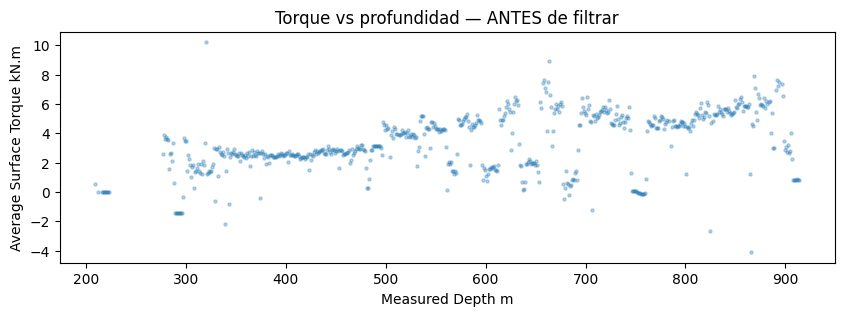

In [ ]:
plt.figure(figsize=(10, 3))
plt.scatter(df_sel['Measured Depth m'], df_sel['Average Surface Torque kN.m'], alpha=0.3, s=5)
plt.xlabel('Measured Depth m')
plt.ylabel('Average Surface Torque kN.m')
plt.title('Torque vs profundidad — ANTES de filtrar')
plt.show()

Se ve lo mismo que en la tabla: la inmensa mayoría de los puntos del Torque en un rango razonable, y un puñado de puntos sueltos por debajo de cero. El otro caso (`Rate of Penetration`) lo vemos en detalle en el bloque de abajo, que es el más extremo. **Decisión: se limpian las dos.**

**Antes de aplicar ningún filtro, busquemos el outlier con nuestros propios ojos** — para saber exactamente qué estamos por sacar, y por qué.

In [ ]:
print('ROP máximo en el archivo, ANTES de filtrar nada:', df_sel['Rate of Penetration m/h'].max())

fila_outlier = df_sel[df_sel['Rate of Penetration m/h'] == df_sel['Rate of Penetration m/h'].max()]
fila_outlier[['Measured Depth m', 'Diameter mm', 'Rate of Penetration m/h']]

ROP máximo en el archivo, ANTES de filtrar nada: 7059.3999022032


,Measured Depth m,Diameter mm,Rate of Penetration m/h
2635,212.001,444.5,7059.399902


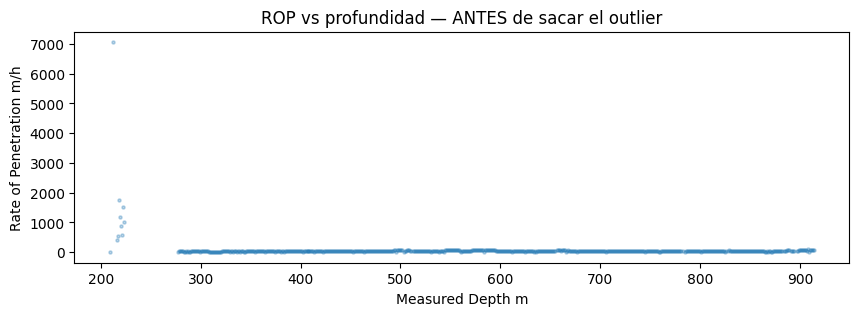

In [ ]:
plt.figure(figsize=(10, 3))
plt.scatter(df_sel['Measured Depth m'], df_sel['Rate of Penetration m/h'], alpha=0.3, s=5)
plt.xlabel('Measured Depth m')
plt.ylabel('Rate of Penetration m/h')
plt.title('ROP vs profundidad — ANTES de sacar el outlier')
plt.show()

Ahí está: un solo punto disparado hasta 7059 m/h, a 212 m de profundidad — todo el resto del pozo queda pegado al piso del gráfico, invisible al lado de ese punto. **Ese es el valor que vamos a sacar ahora, con el código de abajo.**

In [ ]:
def invalidar(col, condicion_valida):
    # 'malos' = tiene un valor real (no es NaN) PERO ese valor no cumple la condicion fisica -> lo pasamos a NaN
    malos = df_sel[col].notna() & ~condicion_valida
    print(f'{col}: {malos.sum()} valores puestos en NaN por ser físicamente imposibles')
    df_sel.loc[malos, col] = np.nan

invalidar('Weight on Bit kkgf', df_sel['Weight on Bit kkgf'] >= 0)                    # no existe peso negativo
invalidar('Mud Flow In L/min', df_sel['Mud Flow In L/min'] >= 0)                      # no existe caudal negativo
invalidar('Mud Density In g/cm3', df_sel['Mud Density In g/cm3'] > 0)                 # la densidad siempre es positiva
invalidar('Average Surface Torque kN.m', df_sel['Average Surface Torque kN.m'] >= 0)  # no existe torque negativo
invalidar('Average Standpipe Pressure kPa', df_sel['Average Standpipe Pressure kPa'] >= 0)  # no existe presión de bombeo negativa
invalidar('Rate of Penetration m/h', df_sel['Rate of Penetration m/h'] >= 0)          # no existe ROP negativo
invalidar('Rate of Penetration m/h', df_sel['Rate of Penetration m/h'] <= 100)        # techo: mismo límite que el script oficial

print()
print('Shape (no cambia, no borramos filas, solo invalidamos valores puntuales):', df_sel.shape)

Weight on Bit kkgf: 0 valores puestos en NaN por ser físicamente imposibles
Mud Flow In L/min: 0 valores puestos en NaN por ser físicamente imposibles
Mud Density In g/cm3: 0 valores puestos en NaN por ser físicamente imposibles
Average Surface Torque kN.m: 26 valores puestos en NaN por ser físicamente imposibles
Average Standpipe Pressure kPa: 0 valores puestos en NaN por ser físicamente imposibles
Rate of Penetration m/h: 0 valores puestos en NaN por ser físicamente imposibles
Rate of Penetration m/h: 9 valores puestos en NaN por ser físicamente imposibles

Shape (no cambia, no borramos filas, solo invalidamos valores puntuales): (19018, 12)


**Nota:** dejamos igual el filtro de `Average Standpipe Pressure >= 0` en el código de abajo, aunque para este pozo ya no borre nada (los valores negativos que tenía pertenecían a la sección de 36in, ya descartada en 6.4). Es una red de seguridad barata — no cuesta nada dejarlo, y protege si en algún momento se vuelve a correr este notebook sin el recorte de 6.4.

**Por qué el techo de 100 m/h en el ROP, y no otro número:** dos razones independientes coinciden en un valor muy parecido, lo cual le da respaldo real a esa cifra:

1. Es el mismo límite que usa el script oficial del dataset (`making_USROP.py`) para todos los pozos.
2. El análisis por rango intercuartílico (IQR) que vamos a hacer en la sección de Outliers, aplicado a este mismo pozo, da un límite superior de **≈103 m/h** — casi el mismo número, calculado de forma completamente independiente.

**Caso real que muestra por qué este orden importa:** en este pozo había una sola fila cruda con un ROP de **7059 m/h** (físicamente imposible — más de 200 veces la mediana del pozo). Si el filtro se hubiera aplicado *después* de `ffill` (como estaba antes), ese valor ya se habría copiado hacia adelante **159 filas**, cubriendo un tramo de más de 4 metros de profundidad con un dato inventado. Filtrando antes, ese dato nunca llega a propagarse.

**Por qué `ffill`/`bfill` y no las otras estrategias típicas de imputación:**

| Estrategia | ¿Por qué no la usamos acá? |
|---|---|
| Eliminar filas con nulos | Ya vimos en la sección 4 que dejaría solo 7 de 21.013 filas — inutilizable. |
| Imputar con una medida global (media/mediana de toda la columna) | "Aplanaría" la variación real del pozo — le asignaría el mismo WOB promedio a todo el pozo, sin importar la profundidad, perdiendo toda la tendencia real que vimos en la sección 8 (ej. la correlación con la profundidad). |
| Imputar por grupo | Necesitaría un grupo natural para agrupar (ej. por tramo de diámetro) — pero dentro de un mismo tramo, el WOB varía muchísimo con la profundidad, así que un promedio por grupo seguiría perdiendo la variación real. |
| **`ffill`/`bfill` (la que usamos)** | Respeta que los datos están **ordenados por profundidad**, no son observaciones intercambiables — el último valor real conocido es la mejor estimación disponible hasta la próxima lectura, y conserva la tendencia real del pozo en vez de aplanarla. Es además el mismo método que usa el paper oficial del dataset. |

Con el orden ya correcto, recién ahora rellenamos los huecos:

In [ ]:
# recien ahora, con el orden ya correcto, rellenamos los huecos
df_sel = df_sel.ffill().bfill()

print('Nulos restantes:', df_sel.isna().sum().sum())
df_sel.isna().sum()

Nulos restantes: 0


,0
Measured Depth m,0
Weight on Bit kkgf,0
Average Hookload kkgf,0
Hole Depth (TVD) m,0
Average Standpipe Pressure kPa,0
Average Surface Torque kN.m,0
USROP Gamma gAPI,0
Mud Density In g/cm3,0
Mud Flow In L/min,0
Rate of Penetration m/h,0


**Verificación: ¿el outlier sigue ahí después de rellenar?** Repetimos exactamente el mismo chequeo de arriba, ahora sobre los datos ya filtrados y rellenados:

ROP máximo, DESPUÉS de filtrar y rellenar: 95.6999969664


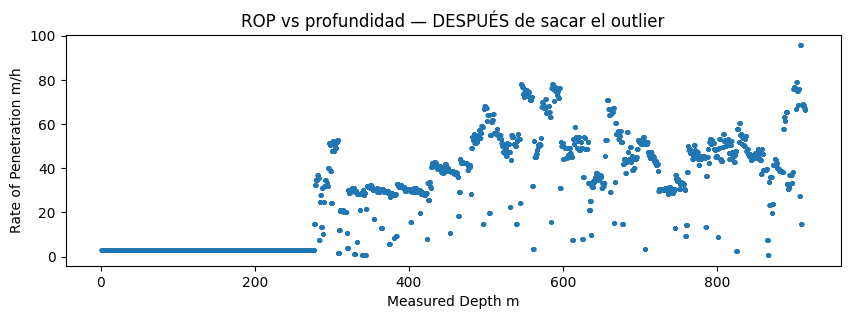

In [ ]:
print('ROP máximo, DESPUÉS de filtrar y rellenar:', df_sel['Rate of Penetration m/h'].max())

plt.figure(figsize=(10, 3))
plt.scatter(df_sel['Measured Depth m'], df_sel['Rate of Penetration m/h'], alpha=0.3, s=5)
plt.xlabel('Measured Depth m')
plt.ylabel('Rate of Penetration m/h')
plt.title('ROP vs profundidad — DESPUÉS de sacar el outlier')
plt.show()

El máximo ahora es coherente con el resto del pozo (menor a 100 m/h, el techo que fijamos), y el gráfico ya no tiene ningún punto disparado — se ve la forma real de la nube de puntos, que antes estaba invisible.

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Conclusión sección 6:** resolvimos, en este orden y no en otro: el problema de orden por profundidad (6.1-6.3), la incompatibilidad de la sección de 36in con el resto del dataset (6.4), y los valores físicamente imposibles antes de rellenar (6.5). Cada paso dependía del anterior — filtrar antes de ordenar, o rellenar antes de filtrar, hubiera dado un resultado distinto y peor (ya lo vimos con el caso del ROP de 7059). El orden de la limpieza es tan importante como la limpieza en sí.

**Y la advertencia que ya adelantamos en la sección 4:** después de todo este trabajo, para el núcleo de variables (WOB, Torque, RPM, Pressure, Hookload, Mud Flow, Mud Density, ROP) seguimos teniendo solo **~638 valores realmente medidos** en las 19.018 filas finales — el resto son copias por `ffill`/`bfill`. No es un error de esta limpieza, es una característica real y ya conocida del dataset. Para el modelo que se entrene más adelante, esto importa: en términos de información independiente, este pozo aporta ~638 puntos, no 19.018 — conviene tenerlo en cuenta al evaluar el modelo (por ejemplo, no partir train/test por fila suelta al azar, sino por bloques de profundidad).

</div>

## 7. Exploración inicial de la data ya limpia

In [ ]:
print('Shape final:', df_sel.shape)
df_sel.describe()

Shape final: (19018, 12)


,Measured Depth m,Weight on Bit kkgf,Average Hookload kkgf,Hole Depth (TVD) m,Average Standpipe Pressure kPa,Average Surface Torque kN.m,USROP Gamma gAPI,Mud Density In g/cm3,Mud Flow In L/min,Rate of Penetration m/h,Average Rotary Speed rpm,Diameter mm
count,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.0
mean,500.480979,4.604684,99.914893,499.824305,12278.251578,2.842051,69.044481,1.215708,3710.132907,32.761016,141.494847,444.5
std,233.929233,5.469438,6.781202,233.081156,4903.631892,2.018415,35.948913,0.111557,1147.437260,20.052108,76.667365,0.0
min,0.000000,0.010197,71.726835,0.000000,401.000022,0.010001,2.403000,0.990000,0.000000,0.630000,0.000000,444.5
25%,316.953000,1.621349,99.707850,316.952224,10869.999696,0.760000,43.255000,1.260000,3515.179932,18.200001,116.000000,444.5
50%,484.164000,3.426246,101.115063,484.152854,13389.999392,2.610000,84.108000,1.270000,4005.189943,33.160000,182.000000,444.5
75%,706.424250,5.435087,103.225876,705.334175,16205.000304,4.610001,93.720000,1.270000,4471.600099,47.490002,210.000000,444.5
max,914.866000,25.615272,106.733694,911.186189,18250.999453,10.210001,242.710000,1.330000,4540.850097,95.699997,212.000000,444.5


<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Conclusión sección 7:**

- El `count` de cada columna ya no varía entre 638 y 21.013 — **todas tienen las 19.018 filas completas**, porque ya no hay nulos.
- El total de filas bajó de 21.013 a **19.018** — la diferencia son las 1.995 filas de la sección de 36in, descartadas en 6.4 para que combine con los otros pozos.
- `Diameter mm` ahora es una columna **constante** (444.5 en todas las filas) — consecuencia directa de haber sacado la sección de 36in.
- Los `min` que antes eran imposibles (Torque, Mud Density, Standpipe Pressure con negativos) **ya son todos físicamente válidos** — para Mud Density y Standpipe Pressure, esto ya venía resuelto por el recorte de 6.4; Torque se resolvió con el filtro de 6.5.
- El `max` del ROP, que antes llegaba a 7059, ahora queda dentro de rango razonable — es la prueba final de que el filtro de 6.5 funcionó de punta a punta.

</div>

## 8. Correlación con el ROP (después de limpiar)

### 8.1 Correlación numérica

In [ ]:
correlaciones = df_sel.corr(numeric_only=True)['Rate of Penetration m/h'].sort_values(ascending=False)
correlaciones

,Rate of Penetration m/h
Rate of Penetration m/h,1.000000
Average Standpipe Pressure kPa,0.799857
Average Rotary Speed rpm,0.780220
Mud Density In g/cm3,0.735255
Mud Flow In L/min,0.716064
Hole Depth (TVD) m,0.678670
Measured Depth m,0.677731
Average Surface Torque kN.m,0.654306
USROP Gamma gAPI,0.629126
Average Hookload kkgf,0.499813


**Comparación con la correlación "antes" (sección 5):** la de acá (sección 8) se calcula sobre los datos ya limpios — ordenados (6.1-6.3), con los valores imposibles ya sacados (6.5, incluido el ROP=7059 m/h) y ya rellenados. Por eso los números van a ser distintos a los de la sección 5, donde todavía no se había hecho nada de eso.

**Un dato que vale la pena tener presente:** ese único valor imposible de ROP, antes de que existiera el filtro de 6.5, el `ffill` lo copiaba hacia adelante en 159 filas seguidas — y ese bloque de 159 valores idénticos y extremos alcanzaba para invertir el signo de casi toda esta tabla de correlaciones. Es la prueba concreta de por qué el orden de los pasos importa: filtrar antes de rellenar (6.5) evita que un solo dato malo contamine el resultado final.

### 8.2 Mapa de calor

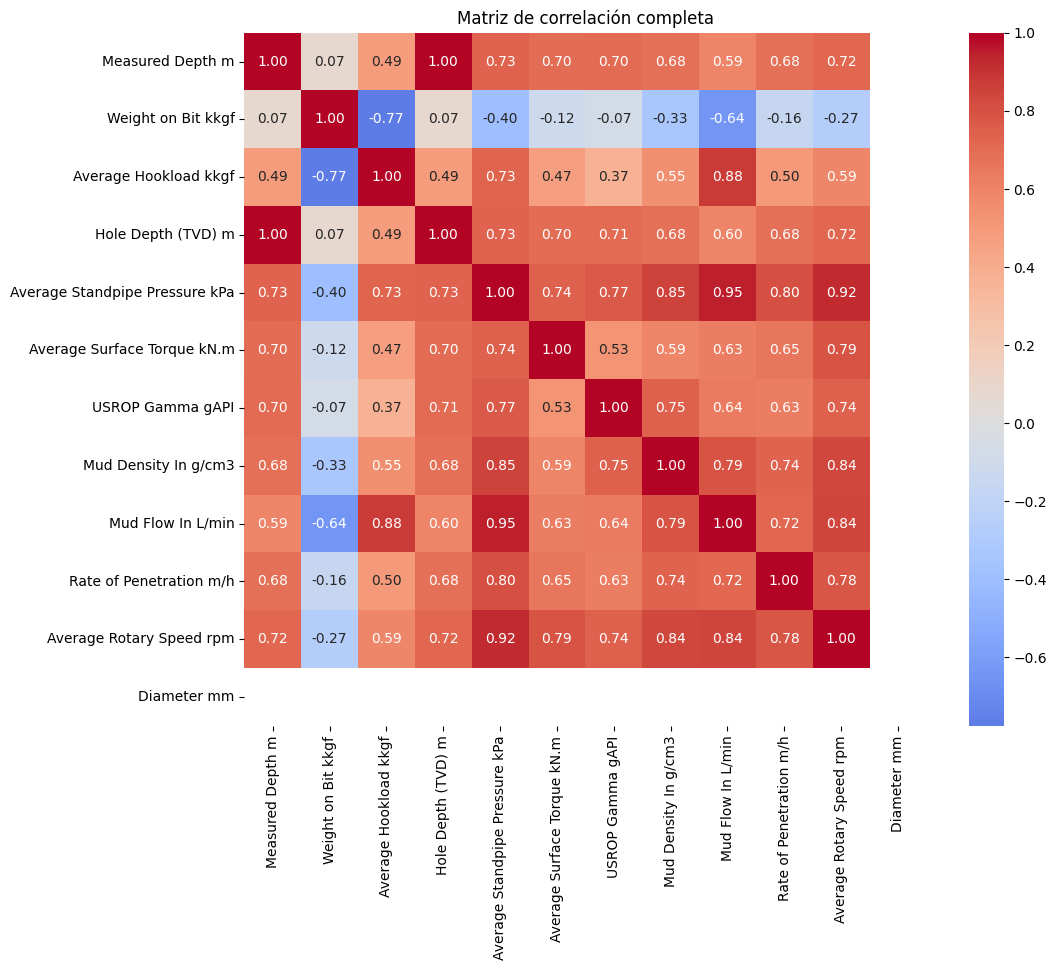

In [ ]:
plt.figure(figsize=(11, 9))
sns.heatmap(df_sel.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación completa')
plt.show()

### 8.3 Qué significa cada variable, y su relación con el ROP

| Variable | Qué es (significado físico) | Corr. vs ROP | Corr. vs Profundidad |
|---|---|---|---|
| `Average Standpipe Pressure kPa` | Presión de bombeo del lodo | **+0.80** | +0.73 |
| `Average Rotary Speed rpm` | Velocidad de rotación de la sarta | **+0.78** | +0.72 |
| `Mud Density In g/cm3` | Densidad del lodo de perforación | +0.74 | +0.68 |
| `Mud Flow In L/min` | Caudal de lodo bombeado | +0.72 | +0.60 |
| `Measured Depth m` / `Hole Depth (TVD) m` | Profundidad medida / vertical verdadera | +0.68 | (es la propia profundidad) |
| `Average Surface Torque kN.m` | Resistencia a la rotación, en superficie | +0.65 | +0.70 |
| `USROP Gamma gAPI` | Rayos gamma naturales (litología) | +0.63 | +0.70 |
| `Average Hookload kkgf` | Peso que cuelga del gancho | +0.50 | +0.49 |
| `Weight on Bit kkgf` | Peso aplicado sobre el trépano | -0.16 | 0.07 |
| `Diameter mm` | Diámetro de la mecha en uso | — (constante) | — (constante) |

**El mismo patrón que ya habíamos visto se mantiene, incluso más marcado ahora:** casi todas las variables con correlación fuerte contra el ROP tienen un número muy parecido contra la profundidad — Pressure (0.80 vs 0.73), Rotary Speed (0.78 vs 0.72), Mud Density (0.74 vs 0.68), Torque (0.65 vs 0.70), Gamma (0.63 vs 0.70). Sigue siendo la firma de **confusión por profundidad (depth confounding)**: no se puede separar del todo cuánto de esa relación es directa contra el ROP, y cuánto es que las dos, por separado, suben con la profundidad.

**`Weight on Bit` sigue siendo la excepción** — la única variable sin relación real con la profundidad (0.07, prácticamente nula), con una correlación débil y negativa contra el ROP (-0.16) que no se explica por confusión con la profundidad. Es una observación genuina de este pozo, no forzada a encajar con la teoría clásica.

**`Diameter mm` ya no tiene fila de correlación** — quedó constante después del recorte de 6.4 (un solo valor, 444.5, en las 19.018 filas), así que no hay variación posible para correlacionar contra nada. Va a volver a ser una variable útil recién cuando combinemos los 7 pozos, donde sí va a variar.

### 8.4 Dispersión (scatter)

Los números de la tabla 8.3 dicen **qué tan fuerte** es cada relación, pero no dicen **cómo se ve** — si es realmente una línea, si los puntos están agrupados, o si el patrón cambia según la zona del pozo. Para eso sirve el scatter. En cada gráfico chico, el eje Y es siempre el ROP, y el eje X es la variable que dice el título; cada punto es una fila del pozo.

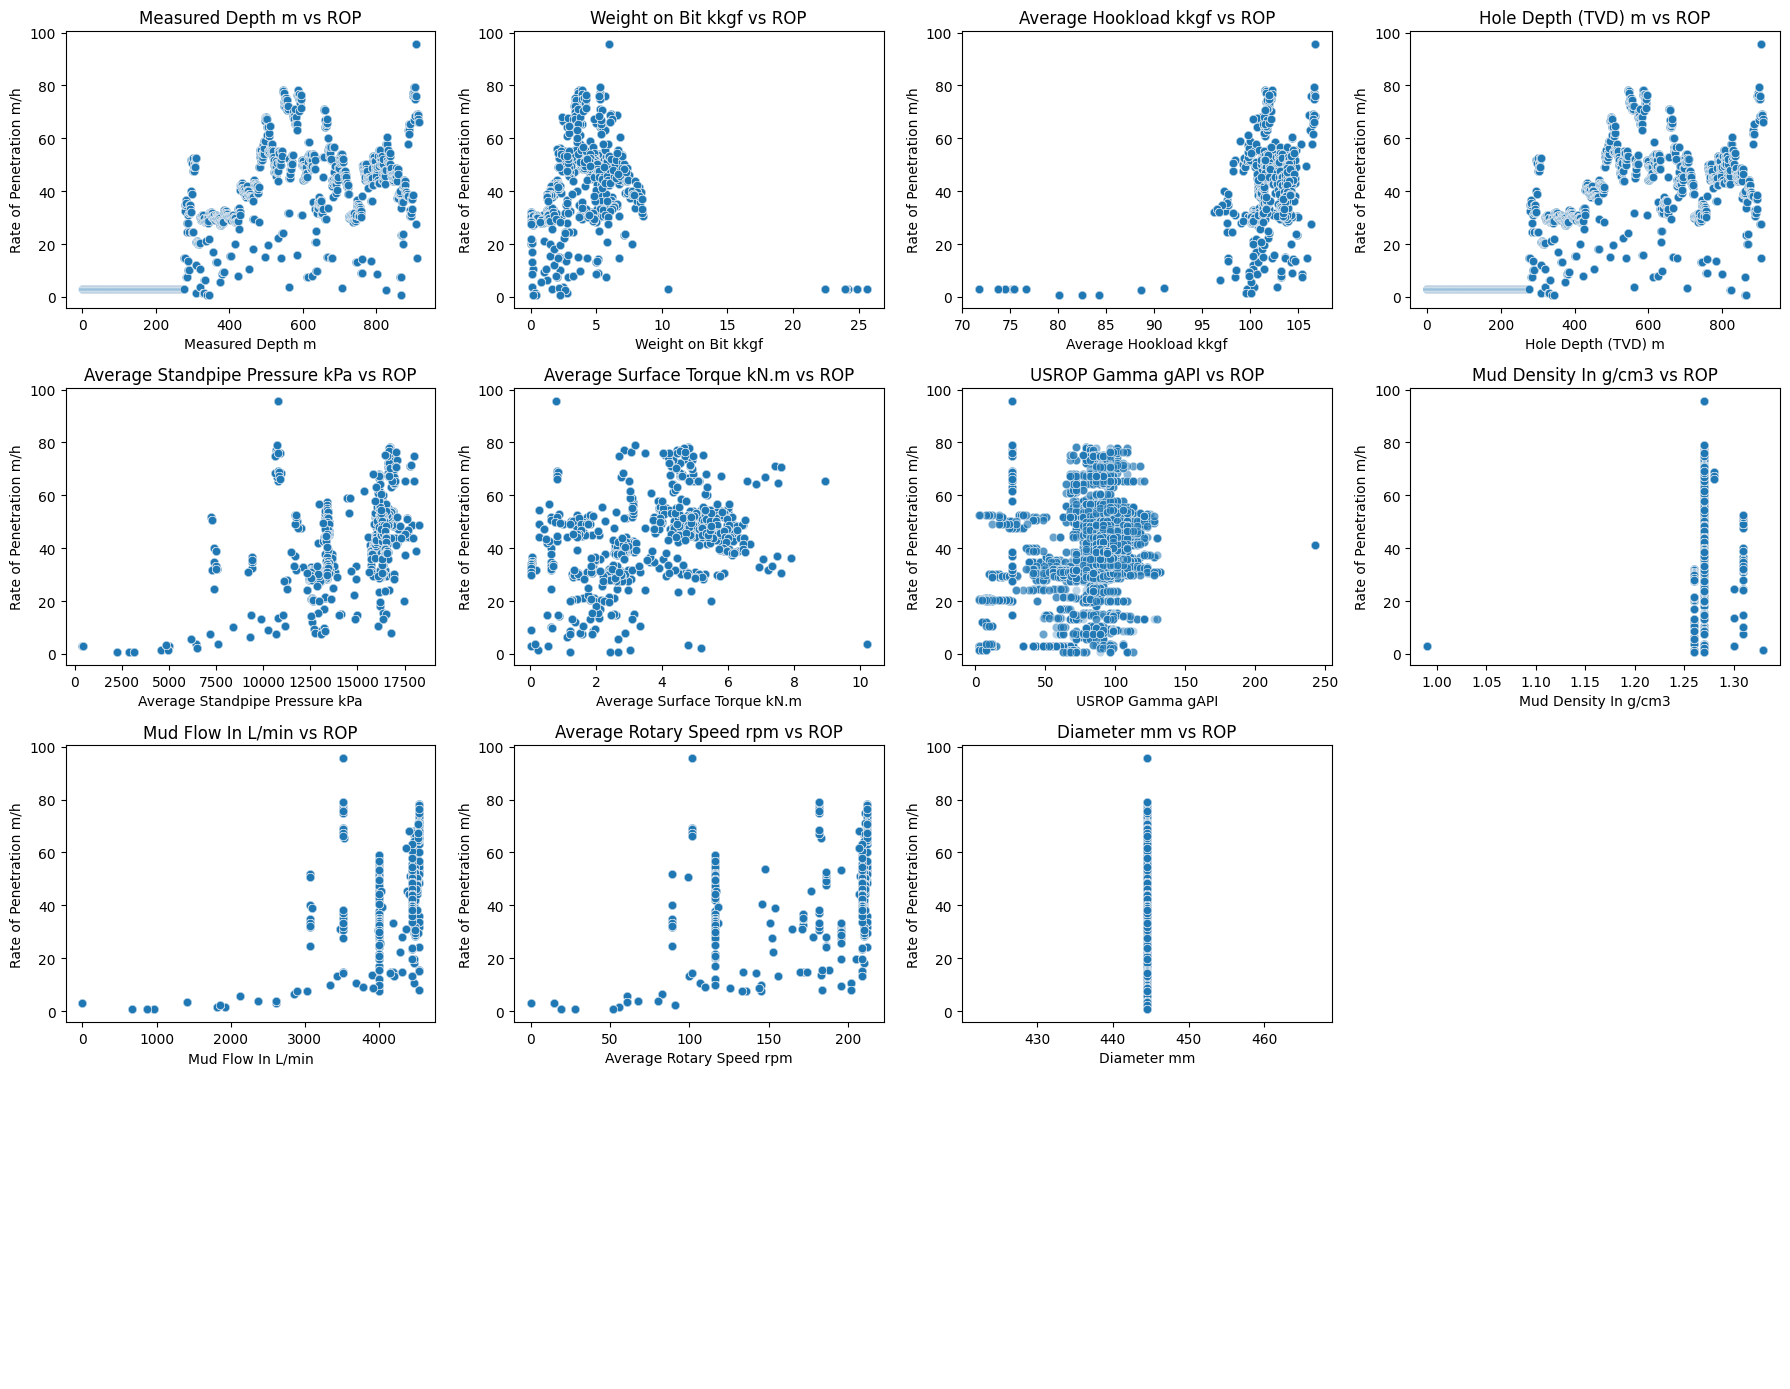

In [ ]:
variables_predictoras = [c for c in df_sel.columns if c != 'Rate of Penetration m/h']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flatten(), variables_predictoras):
    sns.scatterplot(x=df_sel[col], y=df_sel['Rate of Penetration m/h'], ax=ax, alpha=0.3)
    ax.set_title(f'{col} vs ROP')

for ax in axes.flatten()[len(variables_predictoras):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Qué esperar en cada uno, según la correlación de 8.3** (para chequear que el gráfico coincide con el número):

- `Average Standpipe Pressure`, `Average Rotary Speed`, `Mud Density`, `Mud Flow` (r entre 0.72 y 0.80): tendencia ascendente bastante marcada.
- `Measured Depth`, `Average Surface Torque`, `USROP Gamma gAPI` (r entre 0.63 y 0.68): tendencia ascendente más floja, más nube que línea.
- `Average Hookload` (r=0.50): nube con alguna tendencia, pero débil.
- `Weight on Bit` (r=-0.16): nube prácticamente sin forma clara.
- `Diameter mm`: acá no hay nada que ver — como quedó constante después del recorte de 6.4 (un solo valor, 444.5, en todo el pozo), el gráfico va a ser una **única línea vertical** de puntos, sin ninguna dispersión horizontal. No es un error, es la consecuencia esperada de que ya no varía.

Si algún gráfico no se parece a lo que describe su fila de la tabla 8.3, es una señal para volver a mirar esa variable con más cuidado.

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Conclusión sección 8:** la correlación simple no alcanza para explicar el ROP en este pozo. Casi todo lo que correlaciona fuerte con el ROP (Pressure, RPM, Mud Density, Torque, Gamma) también correlaciona igual de fuerte con la profundidad — es decir, no podemos separar del todo si la relación es real o si las dos variables simplemente suben juntas con la profundidad. La única excepción es `Weight on Bit`, sin relación con la profundidad. Vamos a necesitar comparar contra los otros pozos para saber si este patrón se repite o es propio de este pozo.

</div>

## 9. Distribución de cada variable (histogramas)

**Por qué miramos la forma de la distribución antes de tratar outliers:** la forma le dice qué método de detección tiene sentido usar.

- Si una variable se parece a una **campana** (más o menos simétrica), un outlier se puede definir como "algo a más de 3 desvíos estándar de la media" (**z-score**) — en una campana, eso realmente es raro.
- Si una variable está **muy inclinada hacia un lado** (asimétrica, con una cola larga), el z-score no funciona bien: la cola larga ya distorsiona la media y el desvío estándar, así que el propio criterio queda contaminado por lo que se supone que tiene que detectar. Ahí conviene el **rango intercuartílico (IQR)**, que no depende de que la distribución sea simétrica.

El caso más claro de esto en este pozo es el `Rate of Penetration m/h`: incluso después de haber sacado el valor de 7059 m/h (sección 6.5), su histograma va a mostrar una cola larga hacia la derecha — la mayoría de los valores amontonados entre 0 y 50, con una cola más fina que se extiende hasta 100. Esa forma es la pista visual de que, para el ROP, conviene el IQR y no el z-score — exactamente el método que ya usamos en la sección 10.

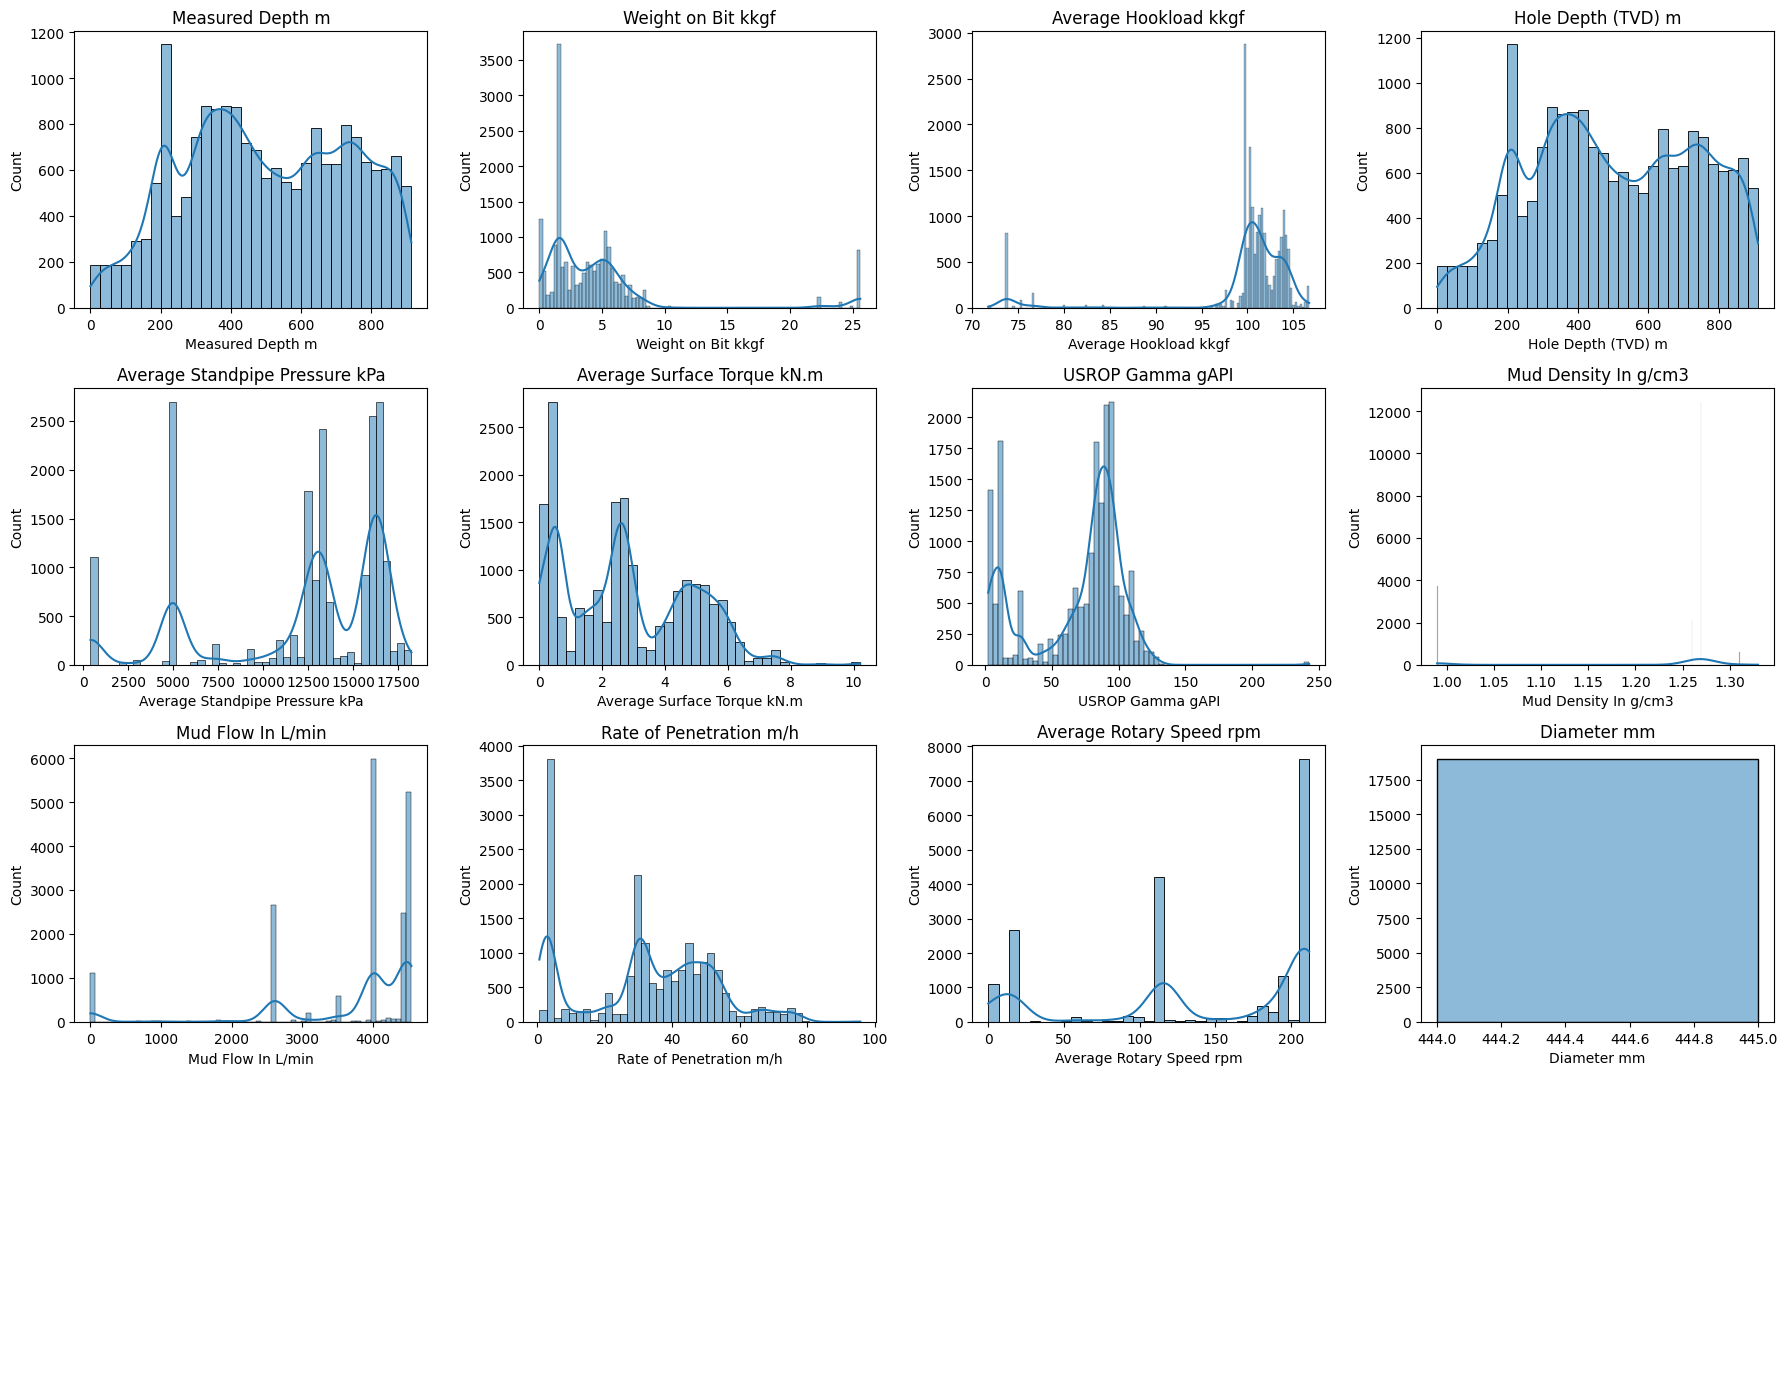

In [ ]:
numeric_cols = df_sel.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df_sel[col], kde=True, ax=ax)
    ax.set_title(col)

for ax in axes.flatten()[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Conclusión sección 9:** la mayoría de las variables del núcleo (`Hookload`, `Mud Flow`, `Standpipe Pressure`, `Mud Density`) muestran distribuciones inclinadas hacia un lado, no de campana — por eso en la sección 10 usamos IQR como criterio principal, y el z-score solo como comparación.

</div>

## 10. Outliers

Un outlier es un valor que se aleja mucho del resto. Acá hay que tener especial cuidado: como rellenamos huecos con `ffill`, es esperable que aparezcan **tramos de valores repetidos** — eso no es necesariamente un outlier ni un error, es una consecuencia directa de la técnica de relleno.

**Dos criterios distintos para lo mismo, para comparar uno contra el otro:**

- **IQR (rango intercuartílico):** usa `Q1` (el valor que deja el 25% de los datos por debajo) y `Q3` (el que deja el 75% por debajo). La diferencia entre los dos es el `IQR`. Todo lo que esté más de 1.5 veces ese rango por debajo de `Q1` o por encima de `Q3` se marca como outlier. No depende de que la variable tenga forma de campana.
- **Z-score:** mide a cuántos **desvíos estándar** de la media está cada valor. `z > 3` significa "a más de 3 desvíos estándar de la media" — un criterio que solo tiene sentido si la variable se parece a una campana (sección 9).

In [ ]:
def contar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return ((serie < limite_inferior) | (serie > limite_superior)).sum()

resultados = []
for col in numeric_cols:
    outliers_iqr = contar_outliers_iqr(df_sel[col])
    z = np.abs(stats.zscore(df_sel[col]))
    outliers_z = (z > 3).sum()
    resultados.append((col, outliers_iqr, outliers_z))

pd.DataFrame(resultados, columns=['Variable', 'Outliers (IQR)', 'Outliers (Z-score)'])

/tmp/ipykernel_4795/2516290264.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z = np.abs(stats.zscore(df_sel[col]))


,Variable,Outliers (IQR),Outliers (Z-score)
0,Measured Depth m,0,0
1,Weight on Bit kkgf,1085,1085
2,Average Hookload kkgf,1228,1104
3,Hole Depth (TVD) m,0,0
4,Average Standpipe Pressure kPa,1159,0
5,Average Surface Torque kN.m,0,49
6,USROP Gamma gAPI,20,20
7,Mud Density In g/cm3,4425,0
8,Mud Flow In L/min,1302,1104
9,Rate of Penetration m/h,17,17


**Para verlo, no solo contarlo:** la tabla de arriba da los números, pero un boxplot muestra la misma información de forma visual — la caja central es donde vive el 50% de los datos (entre Q1 y Q3, lo mismo que usa el IQR), y los puntos sueltos por fuera de los "bigotes" son justamente los outliers que estamos contando.

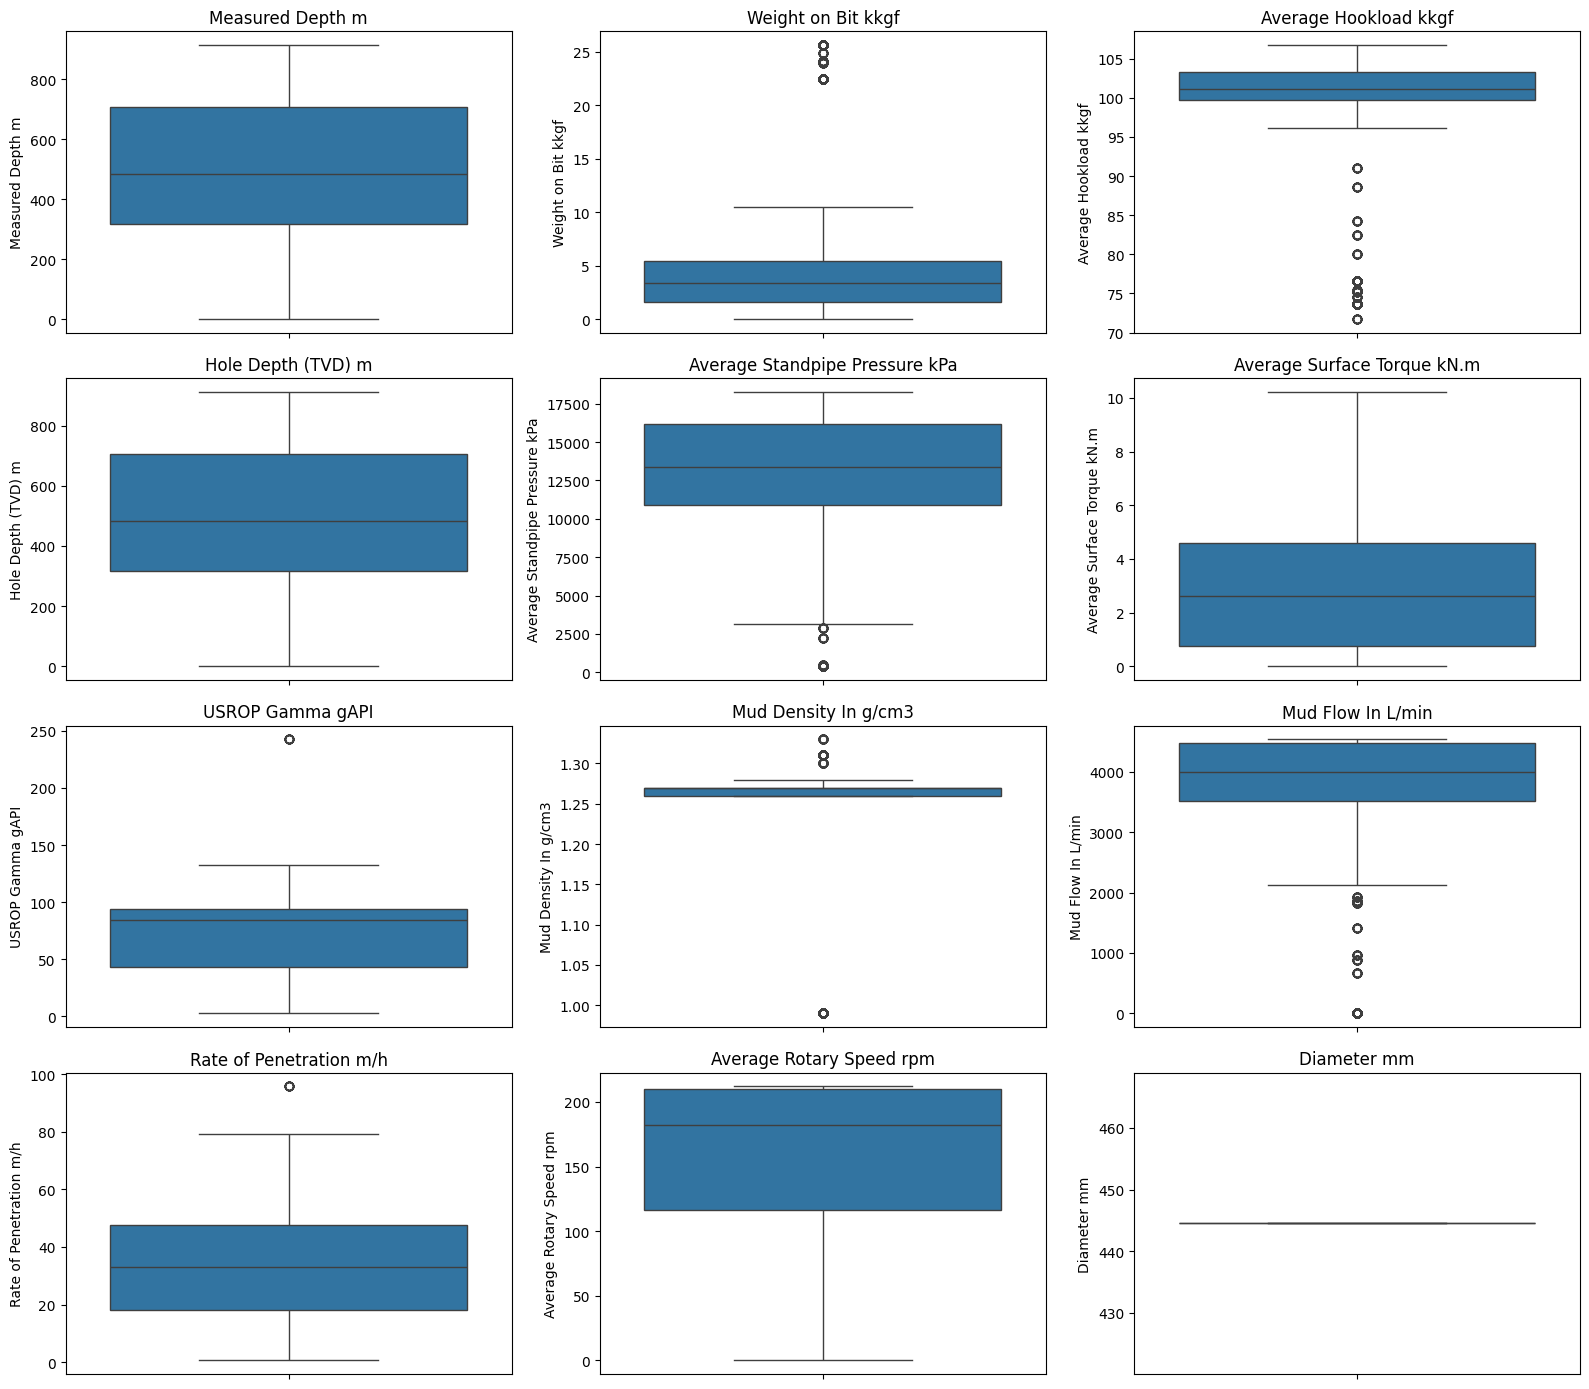

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df_sel[col], ax=ax)
    ax.set_title(col)

for ax in axes.flatten()[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Hipótesis a chequear:** varias columnas podrían dar una cantidad grande de outliers por el mismo motivo — se miden con poca frecuencia real, y el `ffill` estira esos pocos valores reales en bloques de miles de filas repetidas, que el IQR podría interpretar como outlier sin serlo. Los candidatos más obvios por esa razón: `Mud Density`, `Mud Flow In`, `Average Hookload`, `Average Standpipe Pressure`. (`Diameter mm` queda afuera de esta lista — después del recorte de 6.4 es una columna constante, así que no puede tener outliers: nada se aleja de nada si todo es igual.)

In [ ]:
print('Valores únicos reales (antes de rellenar) de Mud Density:', df['Mud Density In g/cm3'].dropna().nunique())
print(df['Mud Density In g/cm3'].dropna().value_counts().head(5))

Valores únicos reales (antes de rellenar) de Mud Density: 11
Mud Density In g/cm3
1.27    530
1.26     67
1.03     59
1.31     29
0.99     23
Name: count, dtype: int64


**El resultado real (tabla de arriba) confirma la hipótesis para las cuatro candidatas — pero por dos mecanismos distintos, no uno solo.** Investigamos con `Mud Density` como caso concreto:

`Mud Density` efectivamente solo tiene un puñado de valores realmente medidos en todo el pozo (la densidad se controla en laboratorio, se ajusta pocas veces por turno) — eso se confirma con el `value_counts` de abajo. Pero el mecanismo por el que se vuelve outlier estadístico es distinto al que esperábamos: como el valor `1.27` domina el pozo (más del 90% de las filas), los cuartiles `Q1` y `Q3` quedan los dos pegados a `1.27` — el `IQR` da casi cero. Con un rango tan angosto, **cualquier otro valor real y legítimo** (como `0.99`, que es una medición de laboratorio válida, no un error) **queda marcado como outlier**, aunque no tenga nada de raro. No es que el dato esté mal — es que el método (IQR) se vuelve hipersensible cuando una sola categoría domina tan fuerte la distribución.

**Conclusión general de la sección:** los conteos de outliers hay que leerlos con esta salvedad — cuando aparecen en variables dominadas por bloques de `ffill` (Mud Density, Mud Flow, Hookload, Standpipe Pressure), no ameritan eliminarse fila por fila, porque el "outlier" está en cómo se distribuye el relleno, no en que el valor medido esté mal.

### 10.1 Interpretación por variable: ¿el outlier es un error, un evento real, o un artefacto del `ffill`?

El conteo de outliers por sí solo no dice nada — dos variables pueden dar el mismo número de outliers por razones completamente distintas. Repasamos cada una:

| Variable | Outliers (IQR) | ¿Por qué? |
|---|---|---|
| `Weight on Bit kkgf` | 1.085 (5.7%) | Cola hacia arriba, hasta 25.6 kkgf — plausible como momentos reales de mayor peso aplicado, sin evidencia de error de sensor. Coherente con ser la única variable **no** confundida con la profundidad (8.3). |
| `Average Surface Torque kN.m` | 0 por IQR, pero **49 por Z-score** | Caso raro: el rango típico del Torque (dado por Q1-Q3) es tan amplio que el IQR no marca nada — pero el z-score sí detecta una cola por encima de la media+3 desvíos. Ejemplo concreto de por qué conviene mirar los dos métodos, no solo uno. |
| `Average Hookload kkgf` | 1.228 (6.5%) | Rango típico angosto (99-103 kkgf) — cualquier desvío, aunque chico en términos absolutos, cae fuera del IQR. Maniobras puntuales (conexiones, cambio de tramo) más que error. |
| `Mud Flow In L/min` | 1.302 (6.8%) | Consistente con períodos de caudal reducido o bomba detenida (conexiones), no con datos corruptos. |
| `Mud Density In g/cm3` | 4.425 (23.3%) | El más alto de todos — pero es un artefacto del método, no un problema real: el valor 1.27 domina tan fuerte el pozo que el IQR queda casi en cero, y cualquier otro valor real (0.99, 1.31, 1.33) queda marcado como outlier aunque sea una medición válida (ver explicación completa arriba). |
| `Average Standpipe Pressure kPa` | 1.159 (6.1%) | Mismo mecanismo que Mud Density: rango típico angosto, así que desvíos moderados pero reales quedan marcados. |
| `Rate of Penetration m/h` | 17 (0.1%) | Ya resuelto en 6.5 — el caso grave (7059 m/h) se sacó antes de rellenar. Lo que queda es variación normal del pozo. |
| `USROP Gamma gAPI` | 20 (0.1%) | Prácticamente ninguno — la litología no cambia de forma abrupta en este pozo. |
| `Diameter mm` | 0 | Constante después del recorte de 6.4 — no puede haber outliers en una variable que no varía. |

<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Conclusión sección 10:** el único outlier que representaba un error real de sensor (el ROP de 7059) ya se resolvió en la sección 6.5, con la evidencia de que su impacto no era menor (159 filas contaminadas, corrió toda la matriz de correlación de la sección 8). El resto de los outliers que quedan son **variación real del pozo** (maniobras, conexiones) o **artefactos del método IQR** cuando una variable está dominada por un solo valor (`Mud Density`, `Standpipe Pressure`) — ninguno de los dos amerita borrarse fila por fila.

</div>

## 11. Estadística descriptiva y valores extremos

In [ ]:
df_sel.describe()

,Measured Depth m,Weight on Bit kkgf,Average Hookload kkgf,Hole Depth (TVD) m,Average Standpipe Pressure kPa,Average Surface Torque kN.m,USROP Gamma gAPI,Mud Density In g/cm3,Mud Flow In L/min,Rate of Penetration m/h,Average Rotary Speed rpm,Diameter mm
count,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.000000,19018.0
mean,500.480979,4.604684,99.914893,499.824305,12278.251578,2.842051,69.044481,1.215708,3710.132907,32.761016,141.494847,444.5
std,233.929233,5.469438,6.781202,233.081156,4903.631892,2.018415,35.948913,0.111557,1147.437260,20.052108,76.667365,0.0
min,0.000000,0.010197,71.726835,0.000000,401.000022,0.010001,2.403000,0.990000,0.000000,0.630000,0.000000,444.5
25%,316.953000,1.621349,99.707850,316.952224,10869.999696,0.760000,43.255000,1.260000,3515.179932,18.200001,116.000000,444.5
50%,484.164000,3.426246,101.115063,484.152854,13389.999392,2.610000,84.108000,1.270000,4005.189943,33.160000,182.000000,444.5
75%,706.424250,5.435087,103.225876,705.334175,16205.000304,4.610001,93.720000,1.270000,4471.600099,47.490002,210.000000,444.5
max,914.866000,25.615272,106.733694,911.186189,18250.999453,10.210001,242.710000,1.330000,4540.850097,95.699997,212.000000,444.5


In [ ]:
fila_rop_max = df_sel['Rate of Penetration m/h'].idxmax()
fila_rop_min = df_sel['Rate of Penetration m/h'].idxmin()

print('Profundidad con ROP máximo:', df_sel.loc[fila_rop_max, 'Measured Depth m'], 'm, ROP =', df_sel['Rate of Penetration m/h'].max())
print('Profundidad con ROP mínimo:', df_sel.loc[fila_rop_min, 'Measured Depth m'], 'm, ROP =', df_sel['Rate of Penetration m/h'].min())

Profundidad con ROP máximo: 907.999 m, ROP = 95.6999969664
Profundidad con ROP mínimo: 338.999 m, ROP = 0.6299999592


<div style="background-color:#fff9db; border-left:6px solid #f1c40f; padding:14px 18px; border-radius:4px;">

**Conclusión sección 11:** el ROP máximo del pozo ya limpio queda en 95.7 m/h, a 908m de profundidad, y el mínimo en 0.63 m/h, a 339m — los dos dentro de un rango físicamente razonable, sin ningún valor disparado. Es la confirmación final de que el pipeline completo (ordenar, recortar, filtrar, rellenar) dejó una tabla lista para combinar con los otros pozos.

</div>

## 12. Guardar el dataset limpio

Guardamos nuestro resultado con un nombre propio, distinto a los archivos originales — **nunca sobrescribimos ni modificamos ningún CSV original**.

In [ ]:
df_sel.to_csv('USROP_A 1 limpio.csv', index=False)
print('Guardado:', df_sel.shape)

Guardado: (19018, 12)


## 13. Próximos pasos

**Necesario para seguir:**
- Combinar este pozo (limpio) con los archivos oficiales de los pozos 0, 2, 3, 4 y 6 — esos ya vienen bien procesados, se usan directamente, sin rehacer nada.
- El **pozo 5 sigue reservado sin tocar**, para la prueba final del modelo.
- **Escalar las variables, recién ahí** (no en este notebook): el escalado tiene que calcularse sobre el conjunto de entrenamiento ya combinado (los 6 pozos juntos), nunca sobre un pozo aislado — si no, cada pozo quedaría escalado con una referencia distinta. Por eso ya importamos `RobustScaler` en la sección 1, como referencia para ese momento: a diferencia de `StandardScaler` (que usa media y desvío estándar, sensibles a outliers) o `MinMaxScaler` (que usa el mínimo y el máximo, todavía más sensible), `RobustScaler` usa la mediana y el rango intercuartílico — coherente con lo que encontramos en las secciones 9 y 10: varias de nuestras variables tienen distribuciones sesgadas y outliers reales (`Weight on Bit`, `Average Hookload`, `Mud Flow`), así que un escalador basado en cuartiles va a ser más robusto que uno basado en la media.

**Opcional (no obligatorio para que el modelo funcione):**
- Confirmar la investigación de outliers para `Mud Flow In` y `Average Hookload`, con el mismo criterio que ya usamos para `Mud Density` y `Average Standpipe Pressure` (sección 10).
- Repetir este mismo proceso de limpieza desde cero en algún otro pozo crudo, si en algún momento se quiere practicar el método o verificar que da el mismo resultado que el archivo oficial ya procesado.

<div style="background-color:#fdecea; border-left:6px solid #e74c3c; padding:14px 18px; border-radius:4px;">

**🔴 Qué pozo usar para cada cosa — para quien retome este proyecto**

| Pozo | Uso | Archivo |
|---|---|---|
| 0, 2, 3, 4 | Entrenamiento | Oficiales, `USROP_A 0/2/3/4...csv` (procesados correctamente) |
| 6 (F-9) | Entrenamiento | Oficial, `USROP_A 6 N-SH_F-9d.csv` — es un pozo real y válido, se puede usar sin problema |
| 1 (F-7) | Entrenamiento | **Nuestra limpieza propia, desde cero, de este notebook** — nunca el archivo oficial (renombrado en la carpeta como `USROP_A 1 N-S_F-7d - NO USAR (bug, es copia de F-9).csv`, para que no se confunda con el nuestro) |
| 5 (F-5) | Prueba final (test) | Oficial, `USROP_A 5 N-SH-F-5d.csv` — reservado, sin tocar hasta evaluar el modelo ya entrenado |

**Por qué el archivo oficial `USROP_A 1` nunca se usa:** no es un error de nuestro criterio, es un bug real del script público del dataset (`making_USROP.py`) — ese archivo (antes se llamaba `USROP_A 1 N-S_F-7d.csv`, lo renombramos para dejarlo claro) en realidad contiene una copia de los datos del pozo 6 (F-9), recortada a partir de los 300m de profundidad (mientras que el archivo oficial del propio pozo 6 se recorta a partir de los 225m). Los dos vienen del mismo pozo real, con distinto corte de profundidad — no son pozos distintos. La confirmación está en el propio código del script oficial (sección revisada en este notebook).

**En resumen: 6 pozos para entrenar (0, 1 propio, 2, 3, 4, 6), 1 pozo reservado para probar (5).**

</div>